# Procesamiento de datos de las corridads con y sin bahia

## Funciones generales

In [1]:

"""
Script para analizar y comparar salidas de MITgcm
con bahía y sin bahía, empleando netCDF vía MITgcmutils / xarray.
 
Incluye:a
1. Lectura de archivos netCDF con MITgcmutils.
2. Funciones para graficar:
   - Batimetría (vista completa y zoom).
   - Velocidades superficiales y verticales.
   - Diferencias entre "con bahía" y "sin bahía".
   - Corte vertical (perfil) de la velocidad vertical.
3. Funciones para generar animaciones de variables (Eta, W, etc.).

Requerimientos:
- numpy, matplotlib, cmocean, MITgcmutils, xarray, seaborn
"""

import numpy as np
import matplotlib.pyplot as plt
import cmocean as cmo
import seaborn as sns
import xarray as xr
import MITgcmutils as MIT
import gsw 
import os, glob

from matplotlib.animation import FuncAnimation

# Ajustar el estilo general de seaborn (opcional)
sns.set_context('notebook')


# --------------------------------------------------------------------
# 1. Lectura de archivos netCDF (con y sin bahía) y carga de variables
# --------------------------------------------------------------------
def cargar_datos_mitgcm(outdir_bay, outdir_nobay, use_wildcard=False):
    """
    Carga archivos netCDF de MITgcm (con bahía y sin bahía) usando MITgcmutils.
    Devuelve un diccionario con:
        nc_bay   : referencias a 'state' con bahía
        nc_nobay : referencias a 'state' sin bahía
        gr_bay   : referencias a 'grid' con bahía
        time     : arreglo de tiempos (segundos)
    """
    # Escoger el patrón según el booleano
    if use_wildcard:
        pattern_bay   = 'state.*.t*.nc'
        pattern_nobay = 'state.*.t*.nc'
    else:
        pattern_bay   = 'state.0000007200.t*.nc'
        pattern_nobay = 'state.0000007200.t*.nc'

    # Cargar (con bahía)
    nc_bay = MIT.mnc_files(outdir_bay + pattern_bay)
    gr_bay = MIT.mnc_files(outdir_bay + 'grid.t*.nc')

    # Cargar (sin bahía)
    nc_nobay = MIT.mnc_files(outdir_nobay + pattern_nobay)

    # Extraer el vector de tiempo de uno de los archivos (asumimos que con bahía hay al menos uno)
    time = nc_bay.variables['T'][:]  # en segundos

    return {
        'nc_bay': nc_bay,
        'nc_nobay': nc_nobay,
        'gr_bay': gr_bay,
        'time': time
    }



# --------------------------------------------------------------------
# 2. Función para graficar la batimetría en vista completa y zoom
# --------------------------------------------------------------------
def plot_bathymetry_full_zoom(gr, X_sym=150, Y_cut=420):
    """
    Dibuja la batimetría (depth) en dos subplots:
    1) Vista completa
    2) Zoom en la región de interés

    Parámetros
    ----------
    gr : referencial netCDF (grid) con variables 'Depth', 'XC', 'YC', 'hFacC', etc.
    X_sym, Y_cut : definen el recorte para el zoom.
    """
    # Extraer variables de gr
    depth = gr.variables['Depth'][:]
    mask = np.ma.getmask(np.ma.masked_values(depth, 0))  # mascara donde depth=0
    XC = gr.variables['XC'][:]
    YC = gr.variables['YC'][:]

    # Definir límites para la escala de color
    vmin = np.nanmin(-depth)
    vmax = np.nanmax(-depth)

    # Figura con 2 subplots
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

    # Subplot 1 (vista completa)
    pc1 = ax1.contourf(
        XC[0, :],
        YC[:, 0],
        np.ma.masked_array(-depth, mask=mask),
        cmap=cmo.cm.deep_r,
        vmin=vmin, vmax=vmax
    )
    ax1.set_aspect('equal')
    ax1.set_facecolor('tan')
    ax1.set_title('Bathymetry (vista completa)')

    # Subplot 2 (zoom)
    X_axis_idx = len(XC[0, :]) // 2  # Centro
    pc2 = ax2.contourf(
        XC[0, X_axis_idx - X_sym : X_axis_idx + X_sym],
        YC[-Y_cut:, 0],
        np.ma.masked_array(
            -depth[-Y_cut:, X_axis_idx - X_sym : X_axis_idx + X_sym],
            mask=mask[-Y_cut:, X_axis_idx - X_sym : X_axis_idx + X_sym]
        ),
        cmap=cmo.cm.deep_r,
        vmin=vmin, vmax=vmax
    )
    ax2.set_aspect('equal')
    ax2.set_facecolor('tan')
    ax2.set_title('Bathymetry (zoom)')

    # Barra de color global
    cbar = fig.colorbar(pc1, ax=[ax1, ax2], label='depth (m)')
    #plt.tight_layout()
    plt.show()


# --------------------------------------------------------------------
# 3. Funciones para graficar variables instantáneas (U, V, W, Eta, etc.)
# --------------------------------------------------------------------
def plot_variable_2d(var2d, X, Y, mask, time_val, varname="Var", units="", 
                     cmap=cmo.cm.balance, vmin=None, vmax=None):
    """
    Grafica una variable 2D (ej. W, Eta) en un pcolormesh, con contorno de la máscara.
    Parámetros
    ----------
    var2d    : np.ndarray 2D con la variable a graficar
    X, Y     : coordenadas (2D o 1D) del dominio
    mask     : máscara para contornear la región de tierra (u otras)
    time_val : valor de tiempo (s, o lo que sea) para el título
    varname  : nombre de la variable (para el título)
    units    : unidades (ej. m/s)
    cmap     : colormap
    vmin,vmax: límites de color
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    mesh = ax.pcolormesh(X, Y, var2d, cmap=cmap, vmin=vmin, vmax=vmax)
    fig.colorbar(mesh, ax=ax, label=f"{varname} ({units})")

    # Contorno de la máscara
    ax.contour(X, Y, mask, colors='black', linewidths=2, linestyles='--')

    # Etiquetas y título
    ax.set_title(f"{varname} a {time_val / 3600:.2f} h")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()


def plot_surface_velocity(nc_bay, nc_nobay, gr, time_index, subtract=False):
    """
    Ejemplo: grafica la velocidad superficial (U y V) para un instante dado (time_index).
    Si subtract=True, grafica la diferencia (bahía - sin bahía).
    """
    # Extraer coordenadas y máscara
    Xp1 = gr.variables['Xp1'][:]
    YC = gr.variables['YC'][:]
    mask = np.ma.getmask(np.ma.masked_values(gr.variables['Depth'][:], 0))
    tval = nc_bay.variables['T'][time_index]

    U_bay = nc_bay.variables['U'][time_index, 0, :, :]
    V_bay = nc_bay.variables['V'][time_index, 0, :, :]
    U_nobay = nc_nobay.variables['U'][time_index, 0, :, :]
    V_nobay = nc_nobay.variables['V'][time_index, 0, :, :]

    if subtract:
        U_plot = U_bay - U_nobay
        varname = "U (bahía - sin bahía)"
    else:
        U_plot = U_bay
        varname = "U (con bahía)"

    plot_variable_2d(
        U_plot, Xp1, YC[:, 0], mask, tval,
        varname=varname, units="m/s",
        cmap=cmo.cm.balance
    )


# --------------------------------------------------------------------
# 4. Funciones para animaciones
# --------------------------------------------------------------------
from matplotlib.patches import Rectangle

def animar_2d_variable(
    nc_bay,
    nc_nobay,
    gr,
    varname='Eta',
    level=0,
    subtract=False,
    stations=None,
    outname="anim_eta.mp4",
    vmin=-0.005,
    vmax=0.005,
    fps=2,
    x_min_center=-238e3,
    x_max_center=238e3,
    y_min=-476e3,
    y_max=0
):
    """
    Crea y guarda una animación 2D de la variable 'varname' con un contorno
    rectangular que delimita la zona definida por los límites dados.

    Parámetros
    ----------
    nc_bay, nc_nobay : netCDF datasets (bahía y sin bahía)
    gr               : netCDF grid (para coordenadas y profundidad)
    varname          : str, nombre de la variable a animar
    level            : int, nivel vertical si la variable es 3D
    subtract         : bool, True => grafica diferencia (bay - noBay)
    stations         : lista de tuplas (i, j, label, color) para estaciones
    outname          : str, nombre del archivo mp4 de salida
    vmin, vmax       : límites de la escala de color
    fps              : frames por segundo
    x_min_center     : coordenada X mínima para el rectángulo (eje X)
    x_max_center     : coordenada X máxima para el rectángulo (eje X)
    y_min            : coordenada Y mínima para el rectángulo (eje Y)
    y_max            : coordenada Y máxima para el rectángulo (eje Y)
    """
    # Coordenadas 1D
    X = gr.variables['XC'][0, :]
    Y = gr.variables['YC'][:, 0]
    mask = np.ma.getmask(np.ma.masked_values(gr.variables['Depth'][:], 0))
    time_data = nc_bay.variables['T'][:]

    # Configuración inicial de datos
    init = nc_bay.variables[varname][0]
    if init.ndim == 3:
        init = init[level, :, :]
    nobay = nc_nobay.variables[varname][0]
    if nobay.ndim == 3:
        nobay = nobay[level, :, :]

    data0 = init - nobay if subtract else init
    title0 = f"{varname} (bay - noBay)" if subtract else f"{varname} (con bahía)"

    fig, ax = plt.subplots(figsize=(8, 6))
    mesh = ax.pcolormesh(X, Y, data0, cmap=cmo.cm.balance, vmin=vmin, vmax=vmax)
    fig.colorbar(mesh, ax=ax, label=varname)
    ax.contour(X, Y, mask, colors='black', linewidths=1.5, linestyles='--')

    # Contorno rectangular de zona de interés
    #ancho = x_max_center - x_min_center
    #alto  = y_max - y_min
    #rect = Rectangle((x_min_center, y_min), ancho, alto,
    #                 linewidth=2, edgecolor='black', facecolor='none')
    #ax.add_patch(rect)

    #ax.set_aspect('equal')
    #ax.set_title(f"{title0} t=0 h")
    #plt.tight_layout()

    # Agregar estaciones si existen
    if stations:
        for i, j, label, color in stations:
            xi, yj = X[i], Y[j]
            ax.plot(xi, yj, 'o', color=color, markersize=8)
            ax.text(xi, yj, label, fontsize=12, ha='left', va='bottom', color=color, weight='bold')

    # Función de actualización
    def update(frame):
        b = nc_bay.variables[varname][frame]
        if b.ndim == 3:
            b = b[level, :, :]
        nb = nc_nobay.variables[varname][frame]
        if nb.ndim == 3:
            nb = nb[level, :, :]
        data = b - nb if subtract else b

        mesh.set_array(data.ravel())
        ax.set_title(f"{title0} t={time_data[frame]/3600:.2f} h")
        return mesh,

    anim = FuncAnimation(fig, update, frames=len(time_data), blit=True)
    anim.save(outname, writer="ffmpeg", fps=fps)
    plt.show()


In [3]:
# --------------------------------------------------------------------
# 5. Función para graficar Eta con corte zoom
# --------------------------------------------------------------------


def animar_2d_variable_zoom(
    nc_bay,
    nc_nobay,
    gr,
    varname='Eta',
    level=0,
    subtract=False,
    outname="anim_eta_zoom.mp4",
    vmin=-0.005,
    vmax=0.005,
    fps=2,
    # Parámetros para el zoom
    X_sym=150,      # número de puntos a la izquierda/derecha del centro en X
    Y_cut=420,      # número de puntos a recortar desde la parte inferior del dominio
):
    """
    Crea y guarda una animación 2D con zoom de la variable 'varname' a lo largo del tiempo.
    Si varname es 3D, se toma el índice 'level' en Z: varname[time, level, y, x].
    subtract=True => (con bahía - sin bahía).

    Zoom:
      - X se recorta ±X_sym alrededor del centro del dominio
      - Y se recorta las últimas Y_cut filas (p.ej. para ver 'la parte de arriba')
    
    Parámetros
    ----------
    nc_bay : netCDF de MITgcm (con bahía).
    nc_nobay : netCDF de MITgcm (sin bahía).
    gr : netCDF grid (para extraer coordenadas, máscaras).
    varname : str, nombre de la variable (ej. 'Eta', 'W', 'U', etc.).
    level : int, nivel vertical (si la variable es 3D).
    subtract : bool, si True se anima la diferencia (bay - noBay).
    outname : str, nombre de archivo mp4 a guardar.
    vmin, vmax : límites de la escala de color.
    fps : frames por segundo para la animación.
    X_sym : define cuántos puntos se toman a la izquierda/derecha del centro en X.
    Y_cut : cuántos puntos se recortan desde la parte inferior en Y (zoom).
    """

    # 1) Extraer coordenadas y máscara
    #    Nota: asumiendo que XC y YC son 2D y tienen la forma (ny, nx).
    XC = gr.variables['XC'][0, :]       # Eje X en la fila 0
    YC = gr.variables['YC'][:, 0]       # Eje Y en la columna 0
    mask_2d = np.ma.getmask(
        np.ma.masked_values(gr.variables['Depth'][:], 0)
    )  # mask donde depth==0
    time_data = nc_bay.variables['T'][:]  # Arreglo de tiempos (s)

    # Dimensión total en X
    nx = len(XC)
    # Centro en X
    X_axis_idx = nx // 2

    # Crear slices para hacer zoom
    # X: [X_axis_idx - X_sym : X_axis_idx + X_sym]
    # Y: [-Y_cut : ] => las últimas Y_cut filas
    x_slice = slice(X_axis_idx - X_sym, X_axis_idx + X_sym)
    y_slice = slice(-Y_cut, None)

    # 2) Leer primer frame para inicializar
    data_bay_init = nc_bay.variables[varname][0]
    if data_bay_init.ndim == 3:
        data_bay_init = data_bay_init[level, :, :]  # shape (ny, nx)
    data_bay_init_zoom = data_bay_init[y_slice, x_slice]

    data_nobay_init = nc_nobay.variables[varname][0]
    if data_nobay_init.ndim == 3:
        data_nobay_init = data_nobay_init[level, :, :]
    data_nobay_init_zoom = data_nobay_init[y_slice, x_slice]

    if subtract:
        data_init = data_bay_init_zoom - data_nobay_init_zoom
        title_str = f"{varname} (bay - noBay)"
    else:
        data_init = data_bay_init_zoom
        title_str = f"{varname} (con bahía)"

    # Recortar también las coordenadas y la máscara
    X_zoom = XC[x_slice]
    Y_zoom = YC[y_slice]
    mask_zoom = mask_2d[y_slice, x_slice]

    # 3) Crear la figura y eje
    fig, ax = plt.subplots(figsize=(8, 6))

    # 4) pcolormesh inicial
    mesh = ax.pcolormesh(
        X_zoom,
        Y_zoom,
        data_init,
        cmap=cmo.cm.balance,
        vmin=vmin,
        vmax=vmax
    )
    cbar = fig.colorbar(mesh, ax=ax, label=f"{varname}")
    ax.contour(
        X_zoom,
        Y_zoom,
        mask_zoom,
        colors='black',
        linewidths=2,
        linestyles='--'
    )
    ax.set_aspect('equal')
    ax.set_title(f"{title_str} t=0 h")
    plt.tight_layout()

    # 5) Función de actualización de cada frame
    def update(frame):
        data_bay = nc_bay.variables[varname][frame]
        if data_bay.ndim == 3:
            data_bay = data_bay[level, :, :]

        data_nobay = nc_nobay.variables[varname][frame]
        if data_nobay.ndim == 3:
            data_nobay = data_nobay[level, :, :]

        # Recortar a la zona de zoom
        data_bay_zoom = data_bay[y_slice, x_slice]
        data_nobay_zoom = data_nobay[y_slice, x_slice]

        if subtract:
            data_zoom = data_bay_zoom - data_nobay_zoom
        else:
            data_zoom = data_bay_zoom

        mesh.set_array(data_zoom.ravel())
        ax.set_title(f"{title_str} t={time_data[frame] / 3600:.2f} h")

        return mesh,

    # 6) Crear la animación
    anim = FuncAnimation(
        fig,
        update,
        frames=range(len(time_data)),
        blit=True
    )

    # 7) Guardar la animación y mostrar
    anim.save(outname, writer="ffmpeg", fps=fps)
    plt.show()

In [1]:
import glob
from MITgcmutils import netcdf

def validate_grid_and_state(outdir, 
                            grid_pattern='grid.t*.nc', 
                            state_pattern='state.*.t*.nc'):
    """
    1) Lee todos los archivos grid.t*.nc bajo outdir, comprueba que se abran
       correctamente y que compartan las mismas dimensiones.
    2) Lee todos los archivos state.*.t*.nc bajo outdir, comprueba lectura y
       dimensiones (ignorando el eje tiempo) contra las de grid.
    """
    # -- GRID --
    grid_files = sorted(glob.glob(outdir + grid_pattern))
    if not grid_files:
        print(f"❌ No se encontraron grids con patrón: {outdir + grid_pattern}")
        return

    ref_dims = None
    print("→ Validando archivos GRID:")
    for f in grid_files:
        try:
            ds = netcdf.netcdf_file(f, 'r')
            dims = dict(ds.dimensions)  # nombre_dim: tamaño
            print(f"   ✔︎ {f} → dims={dims}")
            if ref_dims is None:
                ref_dims = dims
            else:
                if dims != ref_dims:
                    print(f"   ⚠️ Discrepancia en {f}: {dims} != {ref_dims}")
        except Exception as e:
            print(f"   ❌ Error al leer {f}: {e}")
    print()

    # -- STATE --
    state_files = sorted(glob.glob(outdir + state_pattern))
    if not state_files:
        print(f"❌ No se encontraron states con patrón: {outdir + state_pattern}")
        return

    print("→ Validando archivos STATE:")
    for f in state_files:
        try:
            ds = netcdf.netcdf_file(f, 'r')
            # ignorar dimensión de tiempo si existe
            dims = {name: size for name, size in ds.dimensions.items()
                    if name.lower() not in ('t','time')}
            print(f"   ✔︎ {f} → dims={dims}")
            # comparar contra ref_dims
            for dim, gsize in ref_dims.items():
                ssize = dims.get(dim)
                if ssize is None:
                    print(f"      ⚠️ Falta dimensión '{dim}' (esperada {gsize})")
                elif ssize != gsize:
                    print(f"      ⚠️ '{dim}' mismatch: grid={gsize} vs state={ssize}")
        except Exception as e:
            print(f"   ❌ Error al leer {f}: {e}")

if __name__ == '__main__':
    # Ajusta outdir a tu carpeta donde están los .nc
    outdir = '../run_expand*/mnc_000*/'
    validate_grid_and_state(outdir)


→ Validando archivos GRID:
   ✔︎ ../run_expand/mnc_0001/grid.t129.nc → dims={'Z': 50, 'Zp1': 51, 'Zu': 50, 'Zl': 50, 'X': 35, 'Y': 22, 'Xp1': 36, 'Yp1': 23}
   ✔︎ ../run_expand/mnc_0001/grid.t130.nc → dims={'Z': 50, 'Zp1': 51, 'Zu': 50, 'Zl': 50, 'X': 35, 'Y': 22, 'Xp1': 36, 'Yp1': 23}
   ✔︎ ../run_expand/mnc_0001/grid.t131.nc → dims={'Z': 50, 'Zp1': 51, 'Zu': 50, 'Zl': 50, 'X': 35, 'Y': 22, 'Xp1': 36, 'Yp1': 23}
   ✔︎ ../run_expand/mnc_0001/grid.t132.nc → dims={'Z': 50, 'Zp1': 51, 'Zu': 50, 'Zl': 50, 'X': 35, 'Y': 22, 'Xp1': 36, 'Yp1': 23}
   ✔︎ ../run_expand/mnc_0001/grid.t133.nc → dims={'Z': 50, 'Zp1': 51, 'Zu': 50, 'Zl': 50, 'X': 35, 'Y': 22, 'Xp1': 36, 'Yp1': 23}
   ✔︎ ../run_expand/mnc_0001/grid.t134.nc → dims={'Z': 50, 'Zp1': 51, 'Zu': 50, 'Zl': 50, 'X': 35, 'Y': 22, 'Xp1': 36, 'Yp1': 23}
   ✔︎ ../run_expand/mnc_0001/grid.t135.nc → dims={'Z': 50, 'Zp1': 51, 'Zu': 50, 'Zl': 50, 'X': 35, 'Y': 22, 'Xp1': 36, 'Yp1': 23}
   ✔︎ ../run_expand/mnc_0001/grid.t136.nc → dims={'Z': 50, 'Zp1

## Load data 

In [4]:
import xarray as xr, glob, os
one = sorted(glob.glob(os.path.join('../run_expand/mnc_0005/', 'state.0000007200.t001.nc')))[0]
xr.open_dataset(one, engine="netcdf4").close()

In [2]:
# Rutas a los outputs con y sin bahía
outdir_bay = '../run_expand/mnc_00*/'
outdir_nobay = '../run_expand_nobay/mnc_00*/'

# Cargar datos
data_dict = cargar_datos_mitgcm(outdir_bay, outdir_nobay, use_wildcard=False)
nc_bay = data_dict['nc_bay']
nc_nobay = data_dict['nc_nobay']
gr_bay = data_dict['gr_bay']
time = data_dict['time']

In [ ]:
# Definimos las 3 estaciones (i, j, etiqueta, color)
# Supongamos que ya calculaste i_centro, j_centro y radio previamente:
# Por ejemplo:

ny,nx = 352,560
i_centro = nx//2
j_centro = 315
radio    = 50
iA,jA = i_centro-radio, j_centro
iB,jB = i_centro+radio, j_centro
iC,jC = i_centro, j_centro-radio
iG, jG = i_centro, j_centro - 2*radio
iO, jO = i_centro , j_centro



stations = [
    (iA, jA, 'A', '#ea5f94'),
    (iB, jB, 'B', '#0000ff'),
    (iC, jC, 'C', '#fa8775'),
    (iG, jG, 'Gamma', 'limegreen'),
    (iO, jO, 'Omega', 'cyan'),    
]

In [4]:
#muestra las variables disponibles
print("Variables disponibles en el archivo con bahía:")
for var in nc_bay.variables.keys():
    print(var)


Variables disponibles en el archivo con bahía:
T
iter
Xp1
Y
Z
U
X
Yp1
V
Temp
S
Eta
Zl
W


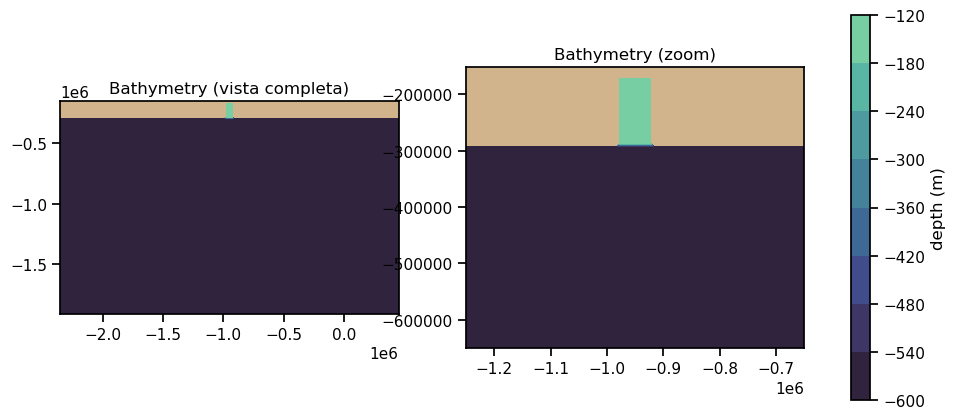

In [7]:
# 1) Graficar bathymetry (vista completa y zoom)
plot_bathymetry_full_zoom(gr_bay, X_sym=60, Y_cut=100)

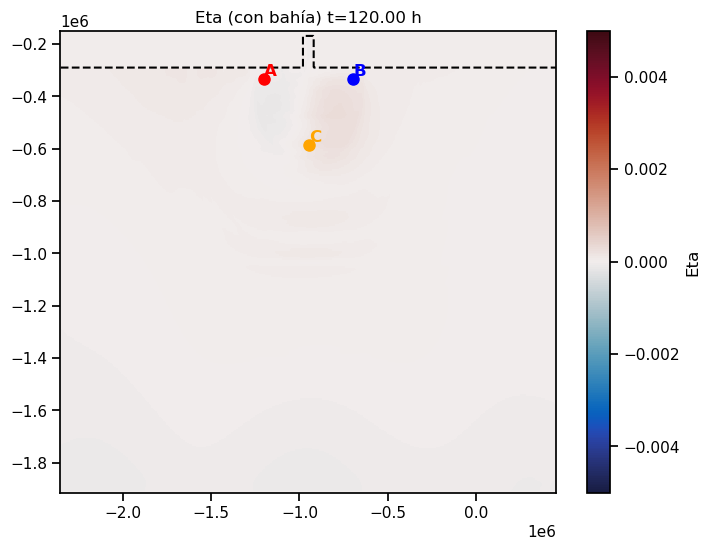

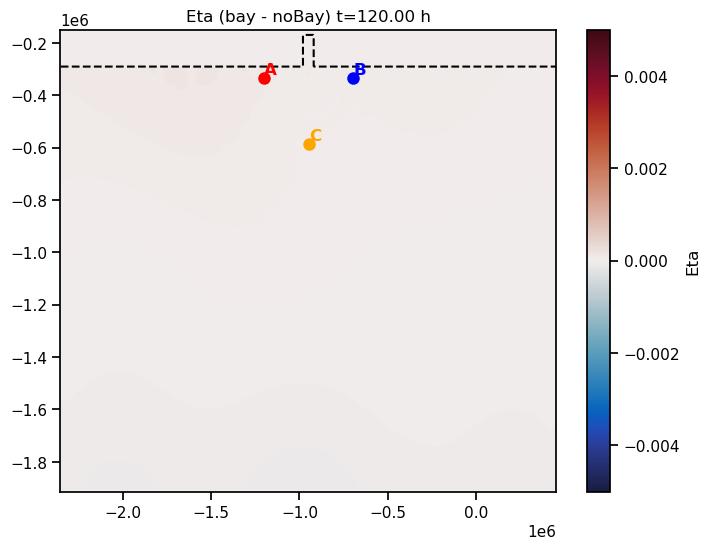

In [7]:
# 3) Animar Eta (superficie libre) con y sin bahía
animar_2d_variable(nc_bay, nc_nobay, gr_bay, varname='Eta', subtract=False, stations=stations, outname="eta_bay_spongeOB_WE_linear_plus120hr.mp4")
animar_2d_variable(nc_bay, nc_nobay, gr_bay, varname='Eta', subtract=True, stations=stations, outname="eta_diff_spongeOB_WE_linear_plus120hr.mp4")


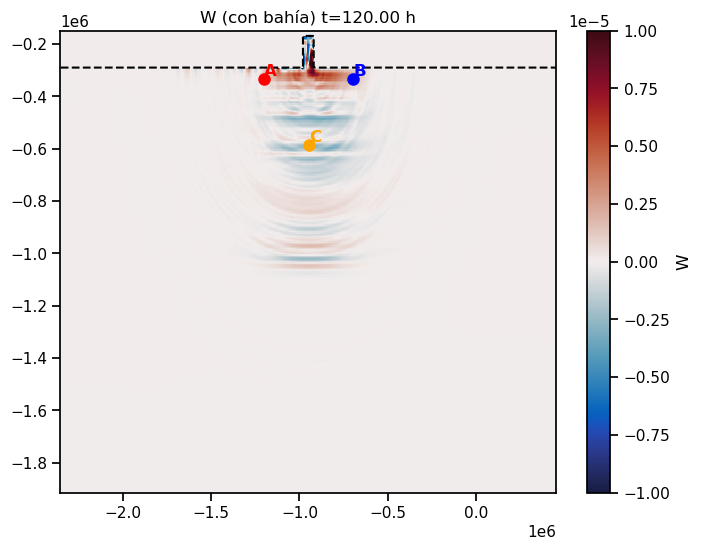

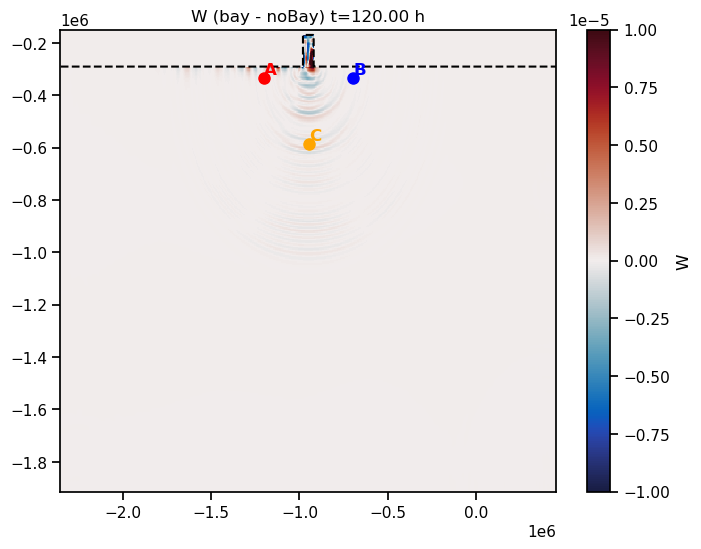

In [8]:
# 4) Animar W a cierta profundidad (p.ej. W[ :,25,:,: ])
animar_2d_variable(nc_bay, nc_nobay, gr_bay, varname='W', level=25, subtract=False, stations=stations, outname="W_bay_spongeOB_WE_2fase_plus120hr.mp4", vmin=-1e-5, vmax=1e-5)
animar_2d_variable(nc_bay, nc_nobay, gr_bay, varname='W', level=25, subtract=True, stations=stations, outname="W_diff_spongeOB_WE_2fase_plus120hr.mp4", vmin=-1e-5, vmax=1e-5)

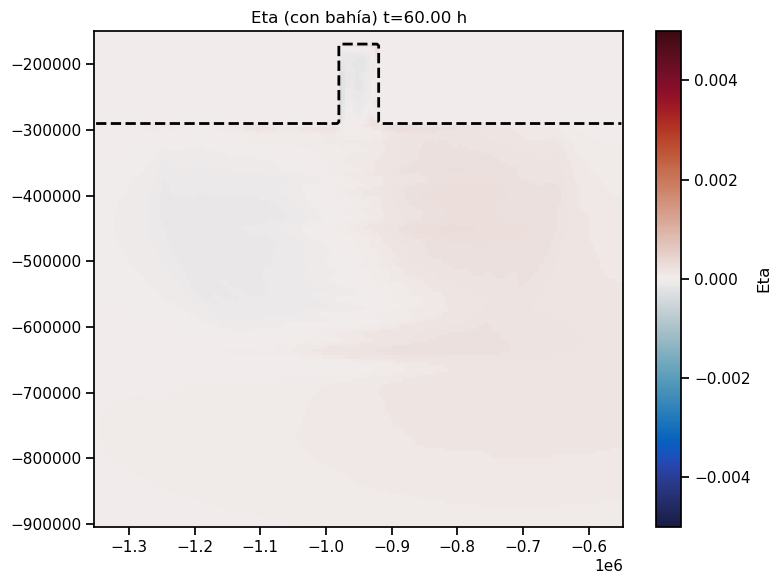

In [17]:
animar_2d_variable_zoom(nc_bay,nc_nobay,gr_bay, varname='Eta', level=0,
    subtract=False, outname="anim_eta_zoom_spongeWE_60hr.mp4", vmin=-0.005, vmax=0.005,
    fps=2,
    # Parámetros para el zoom
    X_sym=80,      # número de puntos a la izquierda/derecha del centro en X
    Y_cut=150,      # número de puntos a recortar desde la parte inferior del dominio
)

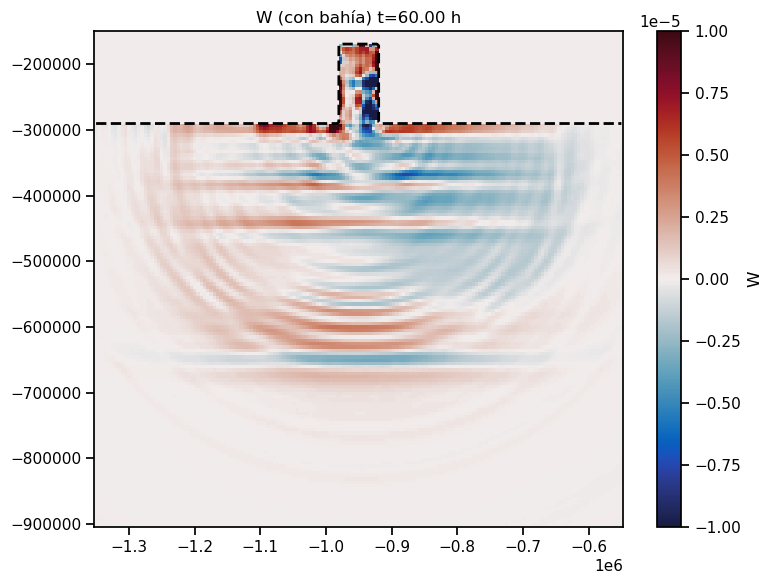

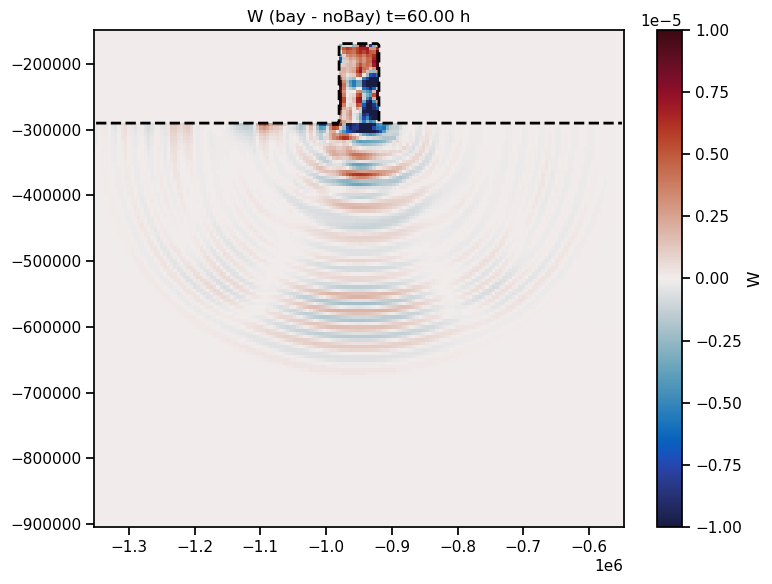

In [12]:
animar_2d_variable_zoom(nc_bay,nc_nobay,gr_bay, varname='W', level=25,
    subtract=False, outname="anim_W_zoom_spongeWE_120hrs.mp4", vmin=-1e-5, vmax=1e-5,
    fps=2,
    # Parámetros para el zoom
    X_sym=80,      # número de puntos a la izquierda/derecha del centro en X
    Y_cut=150,      # número de puntos a recortar desde la parte inferior del dominio
)

animar_2d_variable_zoom(nc_bay,nc_nobay,gr_bay, varname='W', level=25,
    subtract=True, outname="anim_W_diff_zoom_spongeWE_120hrs.mp4", vmin=-1e-5, vmax=1e-5,
    fps=2,
    # Parámetros para el zoom
    X_sym=80,      # número de puntos a la izquierda/derecha del centro en X
    Y_cut=150,      # número de puntos a recortar desde la parte inferior del dominio
)

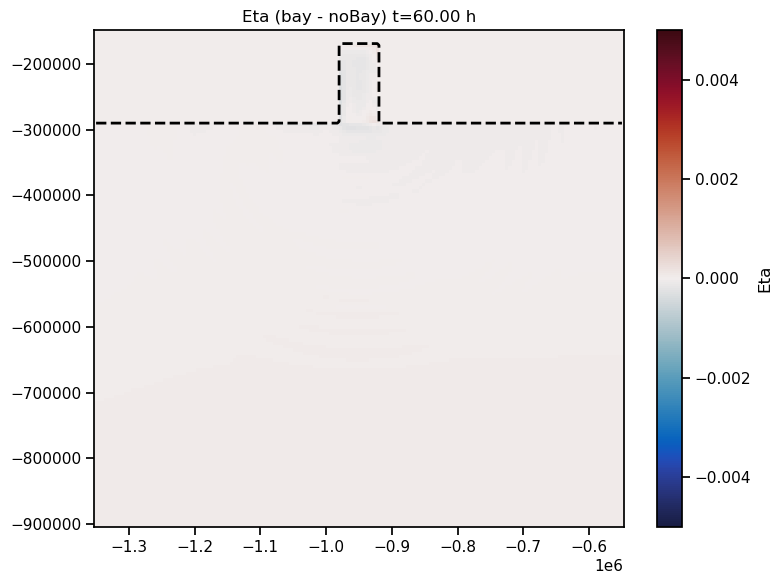

In [13]:
animar_2d_variable_zoom(nc_bay,nc_nobay,gr_bay, varname='Eta', level=0,
    subtract=True, outname="anim_eta_zoom_diff_sponge.mp4", vmin=-0.005, vmax=0.005,
    fps=2,
    # Parámetros para el zoom
    X_sym=80,      # número de puntos a la izquierda/derecha del centro en X
    Y_cut=150,      # número de puntos a recortar desde la parte inferior del dominio
)

In [ ]:
### VIDEOS COMPARACIÓN ETHA

from moviepy import VideoFileClip, clips_array

# Rutas de los videos
video1_path = 'anim_eta_zoom_diff_sponge.mp4'
video2_path = 'anim_eta_zoom_diff.mp4'
#video2_path = 'animationEtha_diff.

# Cargar los videos
clip1 = VideoFileClip(video1_path)
clip2 = VideoFileClip(video2_path)

combined = clips_array([[clip1, clip2]])
combined.preview()

{'video_found': True, 'audio_found': False, 'metadata': {'major_brand': 'isom', 'minor_version': '512', 'compatible_brands': 'isomiso2avc1mp41', 'encoder': 'Lavf61.7.100'}, 'inputs': [{'streams': [{'input_number': 0, 'stream_number': 0, 'stream_type': 'video', 'language': None, 'default': True, 'size': [800, 600], 'bitrate': 23, 'fps': 2.0, 'codec_name': 'h264', 'profile': '(High)', 'metadata': {'Metadata': '', 'handler_name': 'VideoHandler', 'vendor_id': '[0][0][0][0]', 'encoder': 'Lavc61.19.100 libx264'}}], 'input_number': 0}], 'duration': 144.5, 'bitrate': 23, 'start': 0.0, 'default_video_input_number': 0, 'default_video_stream_number': 0, 'video_codec_name': 'h264', 'video_profile': '(High)', 'video_size': [800, 600], 'video_bitrate': 23, 'video_fps': 2.0, 'video_duration': 144.5, 'video_n_frames': 289}
/opt/anaconda3/lib/python3.12/site-packages/imageio_ffmpeg/binaries/ffmpeg-macos-aarch64-v7.1 -i anim_eta_zoom_diff_sponge.mp4 -loglevel error -f image2pipe -vf scale=800:600 -sws_f

/opt/anaconda3/lib/python3.12/site-packages/moviepy/video/io/ffmpeg_reader.py:178: UserWarning: In file anim_eta_zoom_diff.mp4, 3 bytes wanted but 0 bytes read at frame index 0 (out of a total 0 frames), at time 0.00/0.00 sec. Using the last valid frame instead.
  warnings.warn(


OSError: MoviePy error: failed to read the first frame of video file anim_eta_zoom_diff.mp4. That might mean that the file is corrupted. That may also mean that you are using a deprecated version of FFMPEG. On Ubuntu/Debian for instance the version in the repos is deprecated. Please update to a recent version from the website.

In [9]:
def animar_perfil_w(
    nc_bay,
    nc_nobay,
    gr,
    time,
    subtract=False,
    outname="animationWperfil_diff.mp4",
    vmin=-1e-5,
    vmax=1e-5,
    fps=2
):
    """
    Crea y guarda una animación del perfil vertical de la velocidad W
    a lo largo de un corte en X=EjeXBay. Puede usar la diferencia
    (con bahía - sin bahía) o solamente la simulación con bahía.

    Parámetros
    ----------
    nc_bay : netCDF con la simulación "con bahía".
    nc_nobay : netCDF con la simulación "sin bahía".
    time : array-like
        Vector de tiempo (en segundos).
    mask3D : np.ndarray
        Máscara 3D (por ejemplo, HFacC) para contornear la topografía en la sección.
        Debe tener forma [nz, ny, nx].
    YC : np.ndarray
        Coordenadas Y (2D o 1D; para el corte vertical se asume [ny, 1] o [ny]).
    RC : np.ndarray
        Coordenadas verticales, típicamente con shape [nz].
    EjeXBay : int
        Índice de X donde se hará el corte vertical.
    subtract : bool
        Si True, grafica la diferencia W_bay - W_nobay.
        Si False, grafica solo W_bay.
    outname : str
        Nombre del archivo mp4 que se generará.
    vmin, vmax : float
        Límite mínimo y máximo para la escala de colores.
    fps : int
        Frames por segundo para la animación.

    Ejemplo:
        animar_perfil_w(nc, nc2, time, mask3D, YC, RC, EjeXBay=136,
                        subtract=True, outname="animationWperfil_diff1.mp4")
    """
    # Coordenadas
    XC = gr.variables['XC'][0, :]
    YC = gr.variables['YC'][:, 0]
    RC = gr.variables['RC'][:]
    hFacC = gr.variables['HFacC'][:]
    mask3D = np.ma.getmask(np.ma.masked_values(hFacC[:,:], 0))
    EjeXBay= len(XC)//2 # Centro del dominio en X

    # 1) Crear la figura y ejes
    fig, ax = plt.subplots(figsize=(10, 6))

    # 2) Frame inicial (time=0) para dimensionar correctamente el pcolormesh
    W1_init = nc_bay.variables['W'][0, :, :, EjeXBay]  # [z, y]
    if subtract:
        W2_init = nc_nobay.variables['W'][0, :, :, EjeXBay]
        W_init = W1_init - W2_init
        title_base = "Corte vertical (W_bay - W_nobay)"
    else:
        W_init = W1_init
        title_base = "Corte vertical (W con bahía)"

    # 3) Crear pcolormesh inicial
    mesh = ax.pcolormesh(
        YC,  # Eje horizontal (latitud) - asumiendo YC tiene shape [ny, 1]
        RC,        # Eje vertical (profundidad)
        W_init,
        vmin=vmin,
        vmax=vmax,
        cmap=cmo.cm.balance
    )

    # 4) Añadir contorno para la topografía (mask3D=0 => tierra)
    ax.contour(
        YC,
        RC,
        mask3D[:, :, EjeXBay],  # shape [nz, ny]
        colors='black',
        linewidths=2,
        linestyles='--'
    )

    # Barra de color
    fig.colorbar(mesh, ax=ax, label='Velocidad vertical (m/s)')

    # Título inicial
    ax.set_title(f"{title_base} a {time[0]/3600:.2f} horas")

    # Ejes
    ax.set_xlabel("Distancia (m)")
    ax.set_ylabel("Profundidad (m)")

    # Ajustes de layout
    plt.tight_layout()

    # 5) Función de actualización
    def update(frame):
        W1 = nc_bay.variables['W'][frame, :, :, EjeXBay]
        if subtract:
            W2 = nc_nobay.variables['W'][frame, :, :, EjeXBay]
            W_frame = W1 - W2
            ax.set_title(f"{title_base} a {time[frame] / 3600:.2f} horas")
        else:
            W_frame = W1
            ax.set_title(f"{title_base} a {time[frame] / 3600:.2f} horas")

        # Actualizar el pcolormesh
        mesh.set_array(W_frame.ravel())
        return mesh,

    # 6) Crear la animación
    anim = FuncAnimation(
        fig,
        update,
        frames=range(len(time)),
        blit=True
    )

    # 7) Guardar la animación en un archivo mp4
    anim.save(outname, fps=fps, writer="ffmpeg")

    # 8) Mostrar la figura final
    plt.show()

    return anim

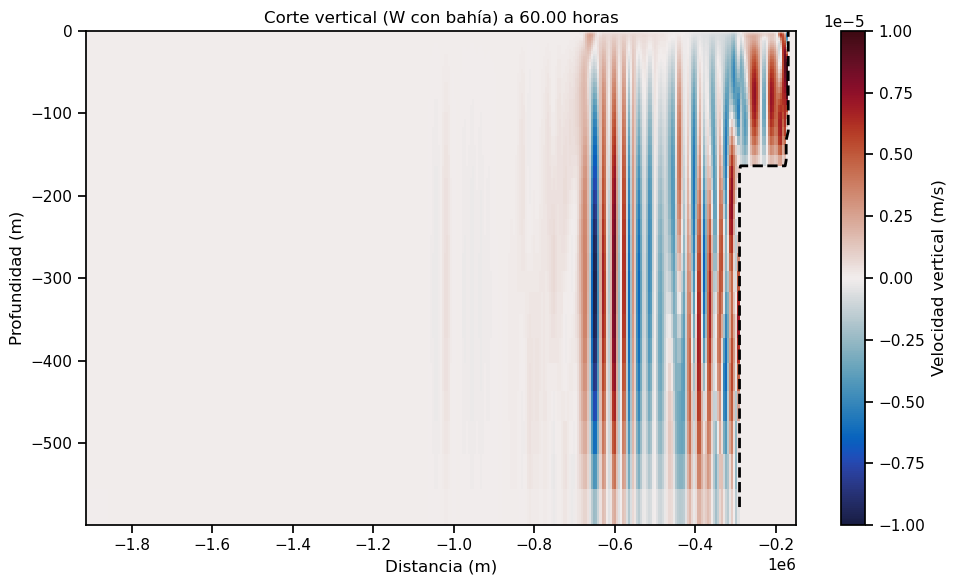

In [19]:
animar_perfil_w(
    nc_bay,
    nc_nobay,
    gr_bay,
    time,
    subtract=False,
    outname="animationWperfil_sponge_lineal_60hr.mp4",
    vmin=-1e-5,
    vmax=1e-5,
    fps=2
)

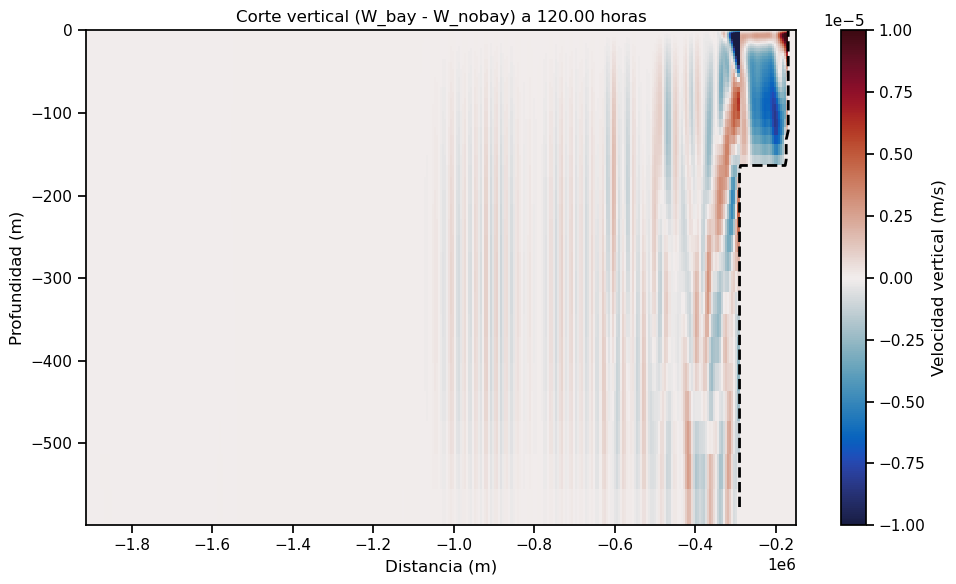

In [10]:
animar_perfil_w(
    nc_bay,
    nc_nobay,
    gr_bay,
    time,
    subtract=True,
    outname="animationWperfil_diff_linear_120hr.mp4",
    vmin=-1e-5,
    vmax=1e-5,
    fps=2
)

In [13]:
from moviepy import VideoFileClip, clips_array

# Rutas de los videos
video1_path = 'animationWperfil_diff_linear_120hr.mp4'
video2_path = 'W_diff_spongeOB_WE_2fase_plus120hr.mp4 '

# Cargar los videos
clip1 = VideoFileClip(video1_path)
clip2 = VideoFileClip(video2_path)

# Crear arreglo lado a lado
combined = clips_array([[clip1, clip2]])

# FPS original
original_fps = clip1.fps

# Para duplicar la cantidad de FPS
fps_double = int(original_fps * 2)

# Para dividir a la mitad la cantidad de FPS
fps_half = max(1, int(original_fps / 2))

# Elige cuál quieres usar:
new_fps = fps_double   # o fps_half

combined.write_videofile(
    "comparacion_Etha_fps_modificado.mp4",
    codec="libx264",
    audio=False,
    fps=new_fps
)

clip1.close()
clip2.close()
combined.close()


{'video_found': True, 'audio_found': False, 'metadata': {'major_brand': 'isom', 'minor_version': '512', 'compatible_brands': 'isomiso2avc1mp41', 'encoder': 'Lavf61.7.100'}, 'inputs': [{'streams': [{'input_number': 0, 'stream_number': 0, 'stream_type': 'video', 'language': None, 'default': True, 'size': [1000, 600], 'bitrate': 79, 'fps': 2.0, 'codec_name': 'h264', 'profile': '(High)', 'metadata': {'Metadata': '', 'handler_name': 'VideoHandler', 'vendor_id': '[0][0][0][0]', 'encoder': 'Lavc61.19.100 libx264'}}], 'input_number': 0}], 'duration': 120.5, 'bitrate': 79, 'start': 0.0, 'default_video_input_number': 0, 'default_video_stream_number': 0, 'video_codec_name': 'h264', 'video_profile': '(High)', 'video_size': [1000, 600], 'video_bitrate': 79, 'video_fps': 2.0, 'video_duration': 120.5, 'video_n_frames': 241}
/opt/anaconda3/lib/python3.12/site-packages/imageio_ffmpeg/binaries/ffmpeg-macos-aarch64-v7.1 -i animationWperfil_diff_linear_120hr.mp4 -loglevel error -f image2pipe -vf scale=100

/opt/anaconda3/lib/python3.12/site-packages/moviepy/video/io/ffmpeg_reader.py:178: UserWarning: In file W_diff_spongeOB_WE_2fase_plus120hr.mp4 , 3 bytes wanted but 0 bytes read at frame index 0 (out of a total 0 frames), at time 0.00/0.00 sec. Using the last valid frame instead.
  warnings.warn(


OSError: MoviePy error: failed to read the first frame of video file W_diff_spongeOB_WE_2fase_plus120hr.mp4 . That might mean that the file is corrupted. That may also mean that you are using a deprecated version of FFMPEG. On Ubuntu/Debian for instance the version in the repos is deprecated. Please update to a recent version from the website.

In [1]:
import os
# Si quieres forzar el uso de una ruta concreta:
os.environ["IMAGEIO_FFMPEG_EXE"] = "/usr/local/bin/ffmpeg"

import moviepy.config as mpc
# También puedes hacer:
mpc.FFMPEG_BINARY = "/usr/local/bin/ffmpeg"

from moviepy.editor import VideoFileClip, clips_array

# Verifica que MoviePy esté apuntando al ffmpeg correcto:
print("FFmpeg que usará MoviePy:", mpc.get_setting("FFMPEG_BINARY"))

# Ahora tu flujo normal
clip1 = VideoFileClip("animationWperfil_diff_sponge.mp4")
clip2 = VideoFileClip("W_diff_spongeOB_WE_2fase_plus120hr.mp4")

combined = clips_array([[clip1, clip2]])
combined.write_videofile(
    "comparacion_reparada.mp4",
    codec="libx264",
    audio=False,
    fps=clip1.fps * 2  # por ejemplo
)

clip1.close()
clip2.close()


ModuleNotFoundError: No module named 'moviepy.editor'

In [ ]:
import os
print("FFmpeg:", os.environ.get("IMAGEIO_FFMPEG_EXE"))




FFmpeg: /usr/local/bin/ffmpeg


In [ ]:
def animar_perfil_w_zoombay(
    nc_bay,
    nc_nobay,
    gr,
    time,
    subtract=False,
    outname="animationWperfil_diff.mp4",
    vmin=-1e-5,
    vmax=1e-5,
    fps=2,
    # Parámetros para el zoom
    RC_cut=-250,      # Limite de profundidad en m a recortar
    YC_cut=420,      # Limite de puntos a recortar desde la parte inferior del dominio
):
    """
    Crea y guarda una animación del perfil vertical de la velocidad W
    a lo largo de un corte en X=EjeXBay. Puede usar la diferencia
    (con bahía - sin bahía) o solamente la simulación con bahía.

    Parámetros
    ----------
    nc_bay : netCDF con la simulación "con bahía".
    nc_nobay : netCDF con la simulación "sin bahía".
    time : array-like
        Vector de tiempo (en segundos).
    mask3D : np.ndarray
        Máscara 3D (por ejemplo, HFacC) para contornear la topografía en la sección.
        Debe tener forma [nz, ny, nx].
    YC : np.ndarray
        Coordenadas Y (2D o 1D; para el corte vertical se asume [ny, 1] o [ny]).
    RC : np.ndarray
        Coordenadas verticales, típicamente con shape [nz].
    EjeXBay : int
        Índice de X donde se hará el corte vertical.
    subtract : bool
        Si True, grafica la diferencia W_bay - W_nobay.
        Si False, grafica solo W_bay.
    outname : str
        Nombre del archivo mp4 que se generará.
    vmin, vmax : float
        Límite mínimo y máximo para la escala de colores.
    fps : int
        Frames por segundo para la animación.

    Ejemplo:
        animar_perfil_w(nc, nc2, time, mask3D, YC, RC, EjeXBay=136,
                        subtract=True, outname="animationWperfil_diff1.mp4")
    """
    # Coordenadas
    XC = gr.variables['XC'][0, :]
    YC = gr.variables['YC'][:, 0]
    RC = gr.variables['RC'][:]
    hFacC = gr.variables['HFacC'][:]
    mask3D = np.ma.getmask(np.ma.masked_values(hFacC[:,:], 0))
    EjeXBay= (len(XC)//2)-1 # Centro del dominio en X

    # Crear slices para hacer zoom
    # RC: [ : RC_cut] => las primeras RC_cut filas
    # Y: [-Y_cut : ] => las últimas Y_cut filas
    RC_filtered = RC[RC > RC_cut]
    Idx_Z=len(RC_filtered)-1
    rc_slice = slice(None, Idx_Z)
    y_slice = slice(-YC_cut, None)

    #Recortar también las coordenadas y la máscara
    Y_zoom = YC[y_slice]
    RC_zoom = RC[rc_slice]
    mask_zoom = mask3D[rc_slice, y_slice]

    # 1) Crear la figura y ejes
    fig, ax = plt.subplots(figsize=(10, 6))

    # 2) Frame inicial (time=0) para dimensionar correctamente el pcolormesh
    W1_init = nc_bay.variables['W'][0, rc_slice, y_slice, EjeXBay]  # [z, y]
    if subtract:
        W2_init = nc_nobay.variables['W'][0, rc_slice, y_slice, EjeXBay]
        W_init = W1_init - W2_init
        title_base = "Corte vertical (W_bay - W_nobay)"
    else:
        W_init = W1_init
        title_base = "Corte vertical (W con bahía)"

    # 3) Crear pcolormesh inicial
    mesh = ax.pcolormesh(
        Y_zoom,  # Eje horizontal (latitud) - asumiendo YC tiene shape [ny, 1]
        RC_zoom,        # Eje vertical (profundidad)
        W_init,
        vmin=vmin,
        vmax=vmax,
        cmap=cmo.cm.balance
    )

    # 4) Añadir contorno para la topografía (mask3D=0 => tierra)
    ax.contour(
        Y_zoom,
        RC_zoom,
        mask_zoom[:, :, EjeXBay],  # shape [nz, ny]
        colors='black',
        linewidths=2,
        linestyles='--'
    )



    # Barra de color
    fig.colorbar(mesh, ax=ax, label='Velocidad vertical (m/s)')

    # Título inicial
    ax.set_title(f"{title_base} a {time[0]/3600:.2f} horas")

    # Ejes
    ax.set_xlabel("Latitud (°)")
    ax.set_ylabel("Profundidad (m)")

    # Ajustes de layout
    plt.tight_layout()

    # 5) Función de actualización
    def update(frame):
        W1 = nc_bay.variables['W'][frame, rc_slice, y_slice, EjeXBay] # [z, y]
        if subtract:
            W2 = nc_nobay.variables['W'][frame, rc_slice, y_slice, EjeXBay] # [z, y]
            W_frame = W1 - W2
            ax.set_title(f"{title_base} a {time[frame] / 3600:.2f} horas")
        else:
            W_frame = W1
            ax.set_title(f"{title_base} a {time[frame] / 3600:.2f} horas")

        # Actualizar el pcolormesh
        mesh.set_array(W_frame.ravel())
        return mesh,

    # 6) Crear la animación
    anim = FuncAnimation(
        fig,
        update,
        frames=range(len(time)),
        blit=True
    )

    # 7) Guardar la animación en un archivo mp4
    anim.save(outname, fps=fps, writer="ffmpeg")

    # 8) Mostrar la figura final
    plt.show()

    return anim

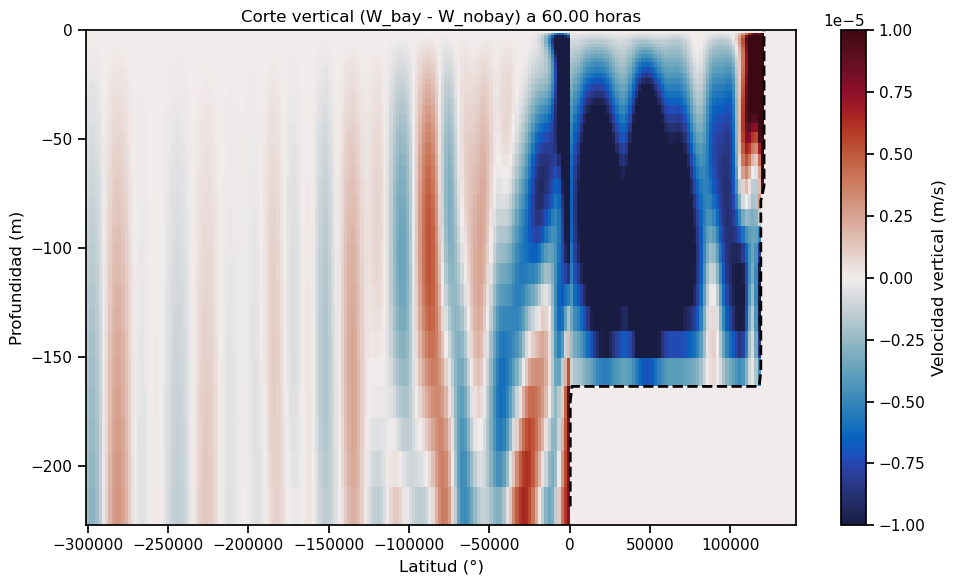

In [ ]:
animar_perfil_w_zoombay(
    nc_bay,
    nc_nobay,
    gr_bay,
    time,
    subtract=True,
    outname="animationWperfil_diff_zoom_60hr_linear.mp4",
    vmin=-1e-5,
    vmax=1e-5,
    fps=2,
    # Parámetros para el zoom
    RC_cut=-250,      # Limite de profundidad en m a recortar
    YC_cut=220,      # Limite de puntos a recortar desde la parte inferior del dominio
)

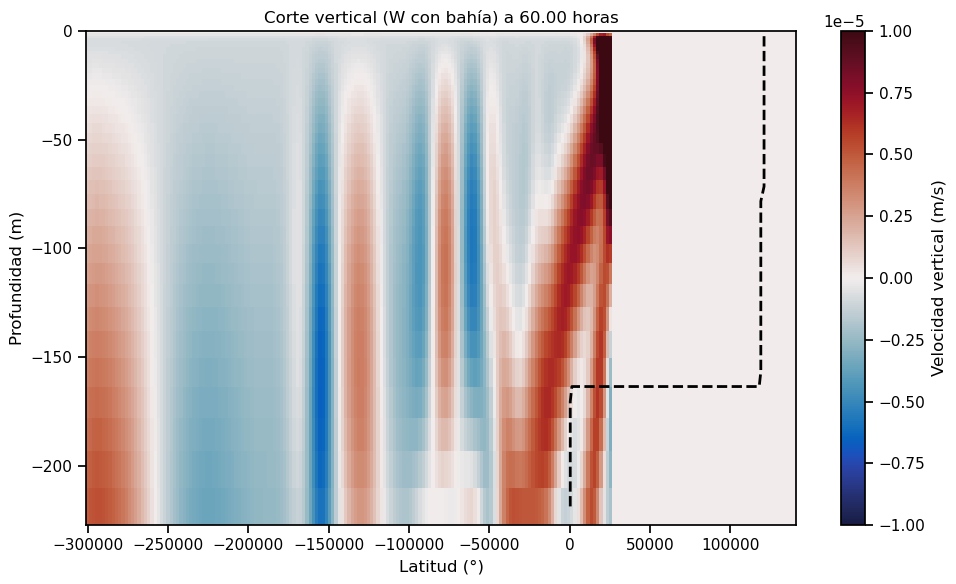

In [ ]:
animar_perfil_w_zoombay(
    nc_nobay,
    nc_bay,
    gr_bay,
    time,
    subtract=False,
    outname="animationWperfil_zoom_60hr_linear.mp4",
    vmin=-1e-5,
    vmax=1e-5,
    fps=2,
    # Parámetros para el zoom
    RC_cut=-250,      # Limite de profundidad en m a recortar
    YC_cut=220,      # Limite de puntos a recortar desde la parte inferior del dominio
)

## Evaluacion de estación dentro de la bahía

In [ ]:
def plot_bathymetry_full_zoom_with_station(gr, X_sym=150, Y_cut=420, 
                                           i_st=179, j_st=466):
    """
    Dibuja la batimetría (depth) en 2 subplots:
    1) Vista completa
    2) Zoom en la región de interés
    
    y superpone un marcador en (j_st, i_st).
    """
    # Extraer variables de gr
    depth = gr.variables['Depth'][:]
    mask = np.ma.getmask(np.ma.masked_values(depth, 0))  # mascara donde depth=0
    XC = gr.variables['XC'][:]
    YC = gr.variables['YC'][:]

    # Definir límites para la escala de color
    vmin = np.nanmin(-depth)
    vmax = np.nanmax(-depth)

    # Figura con 2 subplots
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

    # Subplot 1 (vista completa)
    pc1 = ax1.contourf(
        XC[0, :]/1000,
        YC[:, 0]/1000,
        np.ma.masked_array(-depth, mask=mask),
        cmap=cmo.cm.deep_r,
        vmin=vmin, vmax=vmax
    )
    ax1.set_aspect('equal')
    ax1.set_facecolor('tan')
    ax1.set_title('Bathymetry (whole domain)')
    ax1.set_xlabel('X (km)')
    ax1.set_ylabel('Y (km)')
    
    # Marcar la estación también en la vista completa (opcional)
    x_sta = XC[j_st, i_st]
    y_sta = YC[j_st, i_st]
    x_sta /= 1000  # Convertir a km
    y_sta /= 1000  # Convertir a km
    #Estacion b
    x_stb = XC[245, 30]
    y_stb = YC[245, 30]
    x_stb /= 1000  # Convertir a km
    y_stb /= 1000  # Convertir a km
    ax1.plot(x_stb, y_stb, 'bo', markersize=6, label='Station b')
    ax1.plot(x_sta, y_sta, 'ro', markersize=6, label='Station a')
    ax1.legend()

    # Subplot 2 (zoom)
    X_axis_idx = len(XC[0, :]) // 2  # Centro aproximado en X
    pc2 = ax2.contourf(
        XC[0, X_axis_idx - X_sym : X_axis_idx + X_sym]/1000,
        YC[-Y_cut:, 0]/1000,
        np.ma.masked_array(
            -depth[-Y_cut:, X_axis_idx - X_sym : X_axis_idx + X_sym],
            mask=mask[-Y_cut:, X_axis_idx - X_sym : X_axis_idx + X_sym]
        ),
        cmap=cmo.cm.deep_r,
        vmin=vmin, vmax=vmax
    )
    ax2.set_aspect('equal')
    ax2.set_facecolor('tan')
    ax2.set_title('Bathymetry (zoom)')

    # Marcar la estación en el zoom (solo se verá si cae dentro de esos recortes)
    ax2.plot(x_sta, y_sta, 'ro', markersize=8)
    ax2.text(x_sta, y_sta, "Estación", color="white", fontsize=8,
             ha='left', va='bottom')

    # Barra de color global
    cbar = fig.colorbar(pc1, ax=[ax1, ax2], label='depth (m)')
    #plt.tight_layout()
    plt.show()


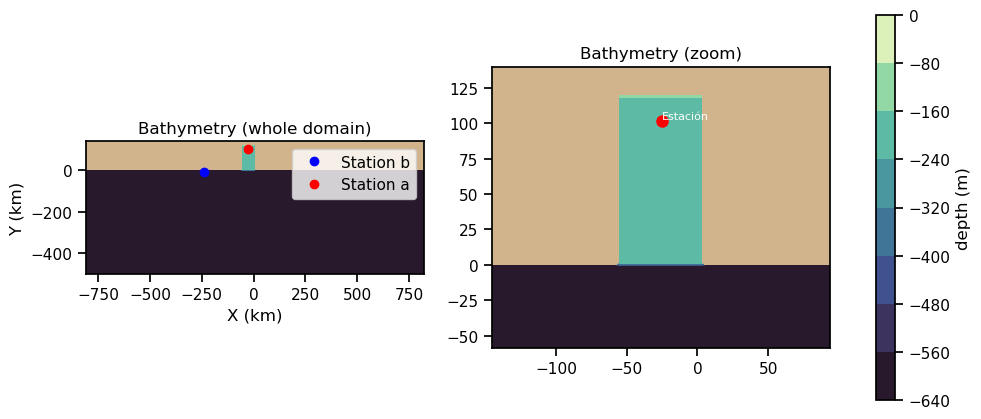

In [ ]:
plot_bathymetry_full_zoom_with_station(gr_bay, X_sym=60, Y_cut=100, 
                                       i_st=136, j_st=300)

In [10]:
jstation, istation = 300, 136

In [13]:
#eta_demean = eta - np.mean(eta)            # quitar sólo la media
# o más completo:
eta_detrend = detrend(eta)                # quitar tendencia lineal

In [14]:
N = len(eta_detrend)  # número de puntos
Y = np.fft.rfft(eta_detrend)   # FFT unilateral (porque la serie es real)
freqs = np.fft.rfftfreq(N, d=dt)  # frecuencias asociadas

# Magnitud del espectro:
amplitud = np.abs(Y)

# Potencia espectral (densidad de potencia "simple"):
PSD = (1.0 / N**2) * np.abs(Y)**2  

# Si quieres la PSD con algo de normalización:
# en procesamiento de señales a veces se hace (2 / (fs*N)) * ...


In [15]:
freq_cph = freqs * 3600.0      # de Hz a ciclos/hora
freq_cpd = freqs * 86400.0     # de Hz a ciclos/día


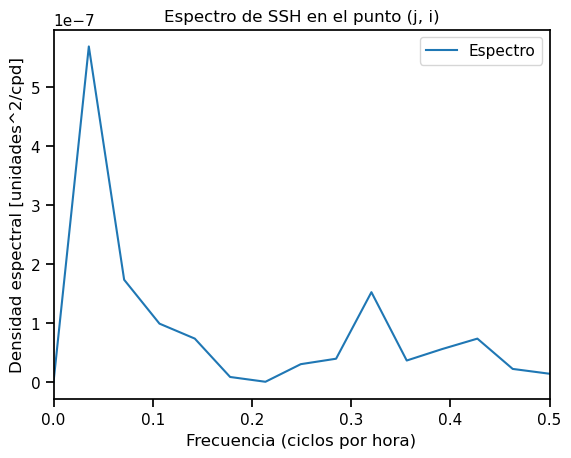

In [16]:
plt.figure()
plt.plot(freq_cph, PSD, label='Espectro')
plt.xlim(0, 0.5)  # ejemplo de rango de frecuencia
plt.xlabel('Frecuencia (ciclos por hora)')
plt.ylabel('Densidad espectral [unidades^2/cpd]')
plt.title('Espectro de SSH en el punto (j, i)')
plt.legend()
plt.show()


In [34]:
# Frecuencia analitica del seiche
# Formula de la frecuencia de seiche
# T_0=2.220[2L/(gh_1)^{1/2}]
# Dimensiones de la bahía
L = 119000  # Longitud de la bahía (m)
H = 164  # Profundidad en la boca (m)
g=9.81 # m/s^2
T_0 = 2.00 * (2*L / ((g*H)**0.5))
f_0 = 1 / T_0
print(f"Frecuencia de seiche: {f_0:.6f} ciclos por segundo")
print(f"Frecuencia de seiche: {f_0*3600:.6f} ciclos por hora")
print(f"Periodo de seihe {T_0/3600:.6f} horas")

Frecuencia de seiche: 0.000084 ciclos por segundo
Frecuencia de seiche: 0.303356 ciclos por hora
Periodo de seihe 3.296462 horas


### Segunda estación

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cmocean as cmo

def plot_bathymetry_full_zoom_with_station(gr, i_st, j_st, radio=40):
    """
    Dibuja la batimetría (depth) en 2 subplots:
    1) Vista completa
    2) Zoom en la región de interés (radio celdas alrededor de (j_st, i_st))

    Parámetros
    ----------
    gr : objeto netCDF / MITgcmutils
        Contiene variables de la malla (XC, YC, Depth).
    i_st, j_st : int
        Índices (i, j) de la estación, en las dimensiones de la matriz.
    radio : int
        Número de celdas a recortar alrededor de (j_st, i_st) en ambas direcciones.
    """
    # Extraer variables de gr
    depth = gr.variables['Depth'][:]
    XC = gr.variables['XC'][:]
    YC = gr.variables['YC'][:]

    # Crear una máscara donde depth=0
    mask = np.ma.getmask(np.ma.masked_values(depth, 0))

    # Definir límites para la escala de color
    vmin = np.nanmin(-depth)
    vmax = np.nanmax(-depth)

    # Figura con 2 subplots
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

    # ---------------- Subplot 1 (vista completa) ----------------
    pc1 = ax1.contourf(
        XC[0, :],
        YC[:, 0],
        np.ma.masked_array(-depth, mask=mask),
        cmap=cmo.cm.deep_r,
        vmin=vmin, vmax=vmax
    )
    ax1.set_aspect('equal')
    ax1.set_facecolor('tan')
    ax1.set_title('Bathymetry (vista completa)')

    # Coordenadas (x, y) de la estación para el scatter
    x_sta = XC[j_st, i_st]
    y_sta = YC[j_st, i_st]
    ax1.plot(x_sta, y_sta, 'ro', markersize=6, label='Estación')
    ax1.legend()

    # ---------------- Subplot 2 (zoom alrededor de la estación) ----------------
    # Aseguramos que los índices no se salgan de los límites
    ny, nx = depth.shape
    i_min = max(i_st - radio, 0)
    i_max = min(i_st + radio, nx)
    j_min = max(j_st - radio, 0)
    j_max = min(j_st + radio, ny)

    pc2 = ax2.contourf(
        XC[j_min:j_max, i_min:i_max],
        YC[j_min:j_max, i_min:i_max],
        np.ma.masked_array(-depth[j_min:j_max, i_min:i_max],
                           mask=mask[j_min:j_max, i_min:i_max]),
        cmap=cmo.cm.deep_r,
        vmin=vmin, vmax=vmax
    )
    ax2.set_aspect('equal')
    ax2.set_facecolor('tan')
    ax2.set_title(f'Bathymetry (zoom en {radio} celdas)')

    # Vuelve a dibujar la estación dentro del zoom, si cae en el recorte
    if j_min <= j_st < j_max and i_min <= i_st < i_max:
        ax2.plot(x_sta, y_sta, 'ro', markersize=8)
        ax2.text(x_sta, y_sta, "Estación", color="white", fontsize=8,
                 ha='left', va='bottom')

    # Barra de color global
    cbar = fig.colorbar(pc1, ax=[ax1, ax2], label='depth (m)')
    #plt.tight_layout()
    plt.show()


# -----------------------------#
# Ejemplo de uso:
# plot_bathymetry_full_zoom_with_station(gr,
#                                        i_st=179,
#                                        j_st=466,
#                                        radio=40)


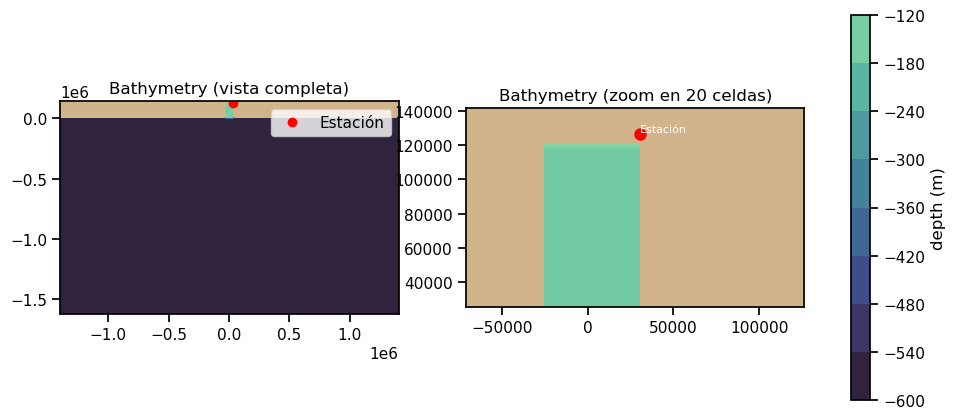

In [29]:
i_st_b, j_st_b = 285, 348

#i_st_b, j_st_b = 75, 248
plot_bathymetry_full_zoom_with_station(gr_bay, i_st_b, j_st_b, radio=20)

In [36]:
#Estachion seiche
i_st, j_st = 278, 330
#j_st, i_st = 136, 300

HFacC_st_seiche = gr_bay.variables['HFacC'][:, j_st, i_st]
print("HFacC en estación seiche:", HFacC_st_seiche)
RC= gr_bay.variables['RC'][:]
Depth_st_seiche = gr_bay.variables['Depth'][j_st, i_st]
print("Profundidad en estación seiche:", Depth_st_seiche)
# Encontrar el nivel vertical más cercano a la profundidad total
nivel_profundo = np.argmax(RC <= -Depth_st_seiche)
print("Nivel vertical más profundo en estación seiche:", nivel_profundo)


HFacC en estación seiche: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
Profundidad en estación seiche: 163.29999999999998
Nivel vertical más profundo en estación seiche: 34


In [37]:
print("HFacC_st_seiche en nivel profundo:", HFacC_st_seiche[nivel_profundo])

HFacC_st_seiche en nivel profundo: 0.0


In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import detrend

def analizar_ssh_y_espectro(nc_bay, nc_nobay, time, jstation, istation):
    """
    Calcula la diferencia de altura superficial (Eta) entre
    configuraciones 'con bahía' y 'sin bahía' en el punto (jstation, istation),
    la grafica contra el tiempo, y luego muestra el espectro de frecuencias
    (calculado con FFT) de dicha señal.

    Parámetros
    ----------
    nc_bay : objeto netCDF (MITgcmutils)
        Contiene la variable 'Eta' para el caso con bahía.
    nc_nobay : objeto netCDF (MITgcmutils)
        Contiene la variable 'Eta' para el caso sin bahía.
    time : array-like
        Vector de tiempo, en segundos.
    jstation, istation : int
        Índices (j, i) de la grilla donde se extrae la serie de tiempo.
    """

    # 1) Extraer valores de 'Eta' (superficie) en la estación dada
    eta_vals_bay = nc_bay.variables['Eta'][:, jstation, istation]
    eta_vals_nobay = nc_nobay.variables['Eta'][:, jstation, istation]

    # 2) Diferencia de altura superficial
    eta_diff = eta_vals_bay - eta_vals_nobay
    t = np.array(time, dtype=float)

    # 3) Graficar la señal de diferencia vs. tiempo (en horas)
    plt.figure(figsize=(6, 4))
    plt.plot(t / 3600.0, eta_diff, label='Eta(bahía) - Eta(sin bahía)')
    plt.xlabel('Tiempo (horas)')
    plt.ylabel('Altura superficial (m)')
    plt.title(f'Diferencia de Eta en (j={jstation}, i={istation})')
    plt.grid(True)
    plt.legend()
    plt.show()

    # 4) Procesar la señal para la FFT
    #    4.1) Asegurar que sea float y remover tendencia
    eta = np.array(eta_diff, dtype=float)
    eta_detrend = detrend(eta)

    #    4.2) Calcular la frecuencia de muestreo
    dt = t[1] - t[0]   # intervalo de muestreo (s)
    fs = 1.0 / dt      # frecuencia de muestreo (Hz)

    #    4.3) FFT unidireccional (porque es una señal real)
    N = len(eta_detrend)
    Y = np.fft.rfft(eta_detrend)           # FFT unilateral
    freqs = np.fft.rfftfreq(N, d=dt)       # vector de frecuencias

    #    4.4) Potencia espectral (forma simple)
    PSD = (1.0 / N**2) * np.abs(Y)**2

    #    4.5) Convertir frecuencias a ciclos/hora (cph) o ciclos/día (cpd)
    freq_cph = freqs * 3600.0

    # 5) Graficar espectro
    plt.figure(figsize=(6, 4))
    plt.plot(freq_cph, PSD, label='Espectro (PSD)')
    plt.xlim(0, 0.8)  # ejemplo de rango en cph
    plt.xlabel('Frecuencia (ciclos/hora)')
    plt.ylabel('Densidad espectral [m^2/cph] (aprox)')
    plt.title(f'Espectro de la diferencia de Eta (j={jstation}, i={istation})')
    plt.grid(True)
    plt.legend()
    plt.show()


## Seiche y espectro

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import detrend

def analizar_ssh_y_espectro_multistation(
    nc_bay, 
    nc_nobay, 
    time, 
    station_list,
    tmin_horas=27.0
):
    """
    Calcula y grafica la diferencia de altura superficial (Eta)
    entre configuraciones 'con bahía' y 'sin bahía' en varias estaciones,
    sobre la misma figura para la serie temporal y otra para la FFT.

    Parámetros
    ----------
    nc_bay : objeto netCDF (MITgcmutils)
        Contiene la variable 'Eta' para el caso con bahía.
    nc_nobay : objeto netCDF (MITgcmutils)
        Contiene la variable 'Eta' para el caso sin bahía.
    time : array-like
        Vector de tiempo, en segundos.
    station_list : list of tuples
        Lista de estaciones, cada una dada como (j_st, i_st).
        Ejemplo: [(300, 136), (305, 142)]
    tmin_horas : float
        Tiempo mínimo (en horas) a partir del cual se recorta la señal.
    """

    # --- Convertimos el vector de tiempo a numpy y calculamos índice de corte ---
    t = np.array(time, dtype=float)
    tmin_seg = tmin_horas * 3600.0
    # Índice donde comienza t >= tmin_seg
    idx_start = np.where(t >= tmin_seg)[0][0] if np.any(t >= tmin_seg) else 0

    # Recortamos el tiempo y convertimos a horas para graficar
    t_cut = t[idx_start:]
    t_cut_horas = t_cut / 3600.0

    # Figura 1: Serie temporal
    plt.figure(figsize=(7, 5))

    # Preparamos colores para cada estación (opcional)
    colors = plt.cm.tab10(np.linspace(0, 1, len(station_list)))

    # Diccionarios para almacenar los resultados de la FFT para graficar luego
    espectros = {}
    frec_cphs = None  # lo definiremos una sola vez (suponiendo que todas tienen mismo dt)

    for (j_st, i_st), color in zip(station_list, colors):
        # 1) Extraer valores de 'Eta' (superficie) en la estación dada (toda la serie)
        eta_vals_bay   = nc_bay.variables['Eta'][:, j_st, i_st]
        eta_vals_nobay = nc_nobay.variables['Eta'][:, j_st, i_st]

        # 2) Convertir a numpy y recortar
        eta_b = np.array(eta_vals_bay, dtype=float)
        eta_n = np.array(eta_vals_nobay, dtype=float)
        eta_b_cut = eta_b[idx_start:]
        eta_n_cut = eta_n[idx_start:]

        # 3) Diferencia de altura superficial
        eta_diff_cut = eta_b_cut - eta_n_cut

        # 4) Graficar la señal de diferencia vs. tiempo (en horas)
        label_str = f'Est. (j={j_st}, i={i_st})'
        plt.plot(t_cut_horas, eta_diff_cut, label=label_str, color=color)

        # 5) Procesar la señal para la FFT
        # 5.1) Quitar tendencia
        eta_detrend = detrend(eta_diff_cut)

        # 5.2) Frecuencia de muestreo (asumimos uniformidad temporal)
        dt = t_cut[1] - t_cut[0] if len(t_cut) > 1 else 1.0
        fs = 1.0 / dt

        # 5.3) FFT unidireccional
        N = len(eta_detrend)
        Y = np.fft.rfft(eta_detrend)
        freqs = np.fft.rfftfreq(N, d=dt)
            

        # 5.4) PSD (simple)
        PSD = (1.0 / N**2) * np.abs(Y)**2

        # 5.5) Frecuencia en ciclos/hora
        freq_cph = freqs * 3600.0

        # Almacenamos para graficar luego
        espectros[(j_st, i_st)] = (freq_cph, PSD)

        # Guardamos las frecuencias si no están definidas aún
        if frec_cphs is None:
            frec_cphs = freq_cph

    # --- Terminamos la figura de la serie temporal ---
    plt.xlabel('Tiempo (horas) desde ' + str(tmin_horas))
    plt.ylabel('Altura superficial (m)')
    plt.title(f'Diferencia Eta (bahía - sin bahía)\nDesde {tmin_horas} h')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Figura 2: Gráfico de espectros en la misma figura
    plt.figure(figsize=(7, 5))

    for ((j_st, i_st), color) in zip(station_list, colors):
        freq_cph, PSD = espectros[(j_st, i_st)]
        label_str = f'Est. (j={j_st}, i={i_st})'
        plt.plot(freq_cph, PSD, label=label_str, color=color)

    plt.xlim(0, 0.8)  # ejemplo de rango
    plt.xlabel('Frecuencia (ciclos/hora)')
    plt.axvline(0.303356, color='k', linestyle='--', linewidth=0.5, label='Frecuencia de seiche')
    plt.ylabel('Densidad espectral [m^2/cph] (aprox)')
    plt.title(f'Espectro de diferencia de Eta\n(Varias estaciones, desde {tmin_horas} h)')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


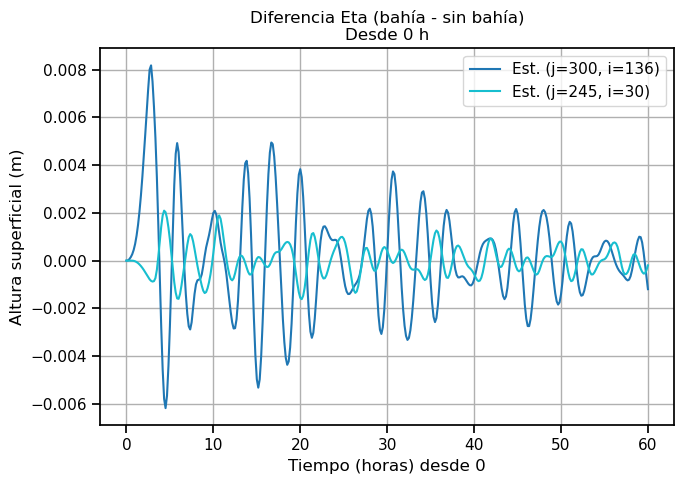

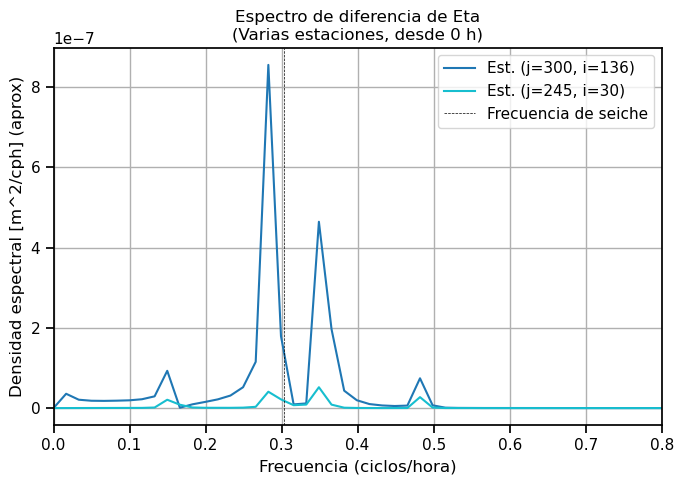

In [5]:
# Estaciones:
jstationA, istationA = 300, 136
jstationB, istationB = 245, 30

station_list = [
    (jstationA, istationA),
    (jstationB, istationB),
]

analizar_ssh_y_espectro_multistation(
    nc_bay,
    nc_nobay,
    time,
    station_list,
    tmin_horas=0
)

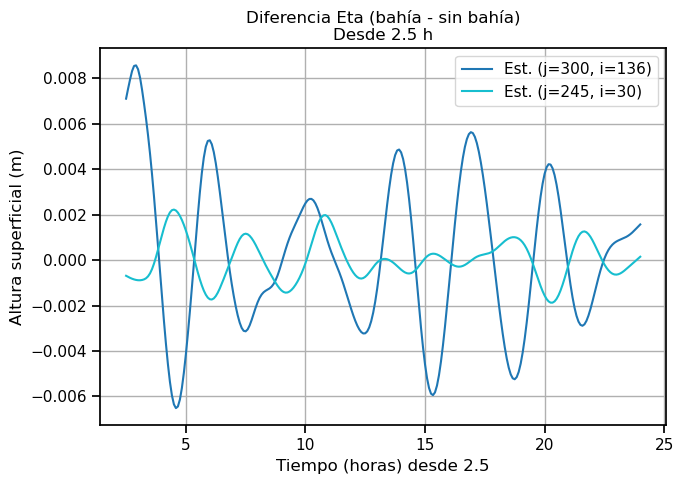

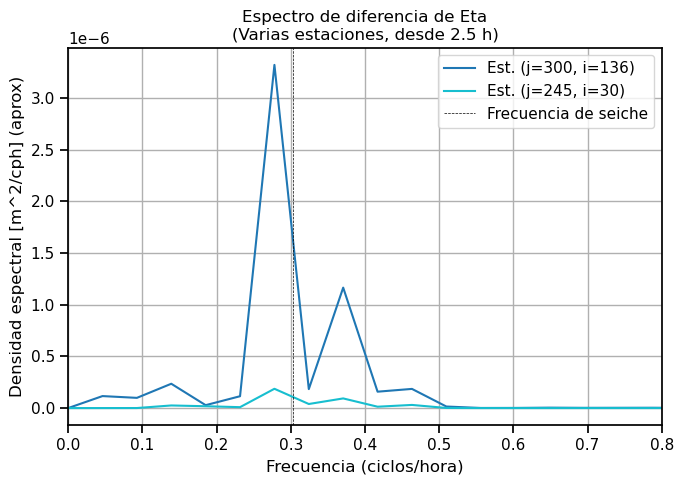

In [8]:
analizar_ssh_y_espectro_multistation(
    nc_bay,
    nc_nobay,
    time,
    station_list,
    tmin_horas=2.5
)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import detrend
import os

def analizar_ssh_y_espectro_multistation(
        nc_bay,
        nc_nobay,
        time,
        station_list,
        tmin_horas=27.0,
        *,
        save_dir=None,
        escenario_tag="escenario",
        formato="npz"
):
    """
    Calcula, grafica y (opcional) guarda la diferencia de Eta y su espectro
    para varias estaciones.

    Parámetros nuevos
    -----------------
    save_dir : str or Path, opcional
        Carpeta donde se escriben los archivos.  Si es None, no se guarda nada.
    escenario_tag : str
        Etiqueta para identificar este escenario en los nombres de archivo.
    formato : {'npz', 'npy'}
        Formato de salida; 'npz' comprime varios arrays, 'npy' un solo array.
    """

    # --- Preparación de tiempo ---
    t   = np.asarray(time, dtype=float)
    idx_start = np.where(t >= tmin_horas*3600)[0][0] if np.any(t >= tmin_horas*3600) else 0
    t_cut        = t[idx_start:]
    t_cut_horas  = t_cut/3600.0

    colors   = plt.cm.tab10(np.linspace(0,1,len(station_list)))
    espectros = {}
    
    # Crear carpeta destino si procede
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    # ---------- Serie temporal ----------
    plt.figure(figsize=(7,5))
    for (j_st,i_st), color in zip(station_list, colors):

        eta_b = np.asarray(nc_bay.variables['Eta'][:, j_st, i_st],   float)
        eta_n = np.asarray(nc_nobay.variables['Eta'][:, j_st, i_st], float)

        eta_b_cut = eta_b[idx_start:]
        eta_n_cut = eta_n[idx_start:]
        eta_diff  = eta_b_cut - eta_n_cut

        plt.plot(t_cut_horas, eta_diff, label=f'Est. (j={j_st}, i={i_st})', color=color)

        # ---------- FFT ----------
        eta_detrend = detrend(eta_diff)
        dt          = t_cut[1]-t_cut[0] if len(t_cut)>1 else 1.0
        N           = len(eta_detrend)
        freqs       = np.fft.rfftfreq(N, d=dt)
        Y           = np.fft.rfft(eta_detrend)
        PSD         = (np.abs(Y)**2)/N**2           # densidad unidireccional
        freq_cph    = freqs*3600.0                  # ciclos/hora

        espectros[(j_st,i_st)] = (freq_cph, PSD, eta_diff)

        # ---------- Guardar ----------
        if save_dir is not None:
            fname = os.path.join(save_dir, f"{escenario_tag}_j{j_st}_i{i_st}.{formato}")
            if formato=="npz":
                np.savez_compressed(fname,
                                    t_h=t_cut_horas,
                                    eta_diff=eta_diff,
                                    freq_cph=freq_cph,
                                    PSD=PSD)
            elif formato=="npy":
                # Guarda dict; tamaño algo mayor pero sencillo de leer
                np.save(fname, {"t_h":t_cut_horas,
                                "eta_diff":eta_diff,
                                "freq_cph":freq_cph,
                                "PSD":PSD})
            else:
                raise ValueError("formato debe ser 'npz' o 'npy'")

    # --- Gráficos ---
    plt.xlabel('Tiempo (h) desde '+str(tmin_horas))
    plt.ylabel('Altura superficial (m)')
    plt.title(f'Diferencia Eta (bahía - sin bahía)\nDesde {tmin_horas} h')
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

    # Espectros
    plt.figure(figsize=(7,5))
    for (j_st,i_st), color in zip(station_list, colors):
        freq_cph, PSD, _ = espectros[(j_st,i_st)]
        plt.plot(freq_cph, PSD, color=color,
                 label=f'Est. (j={j_st}, i={i_st})')
    plt.xlim(0,0.8)
    plt.axvline(0.303356, ls='--', lw=.5, color='k', label='Seiche')
    plt.xlabel('Frecuencia (ciclos/hora)')
    plt.ylabel('PSD [m²/cph]')
    plt.title(f'Espectro de diferencia de Eta\nDesde {tmin_horas} h')
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

    # Devuelve resultados por si los necesitas sin volver a cargar
    return {"t_h":t_cut_horas, "resultados":espectros}


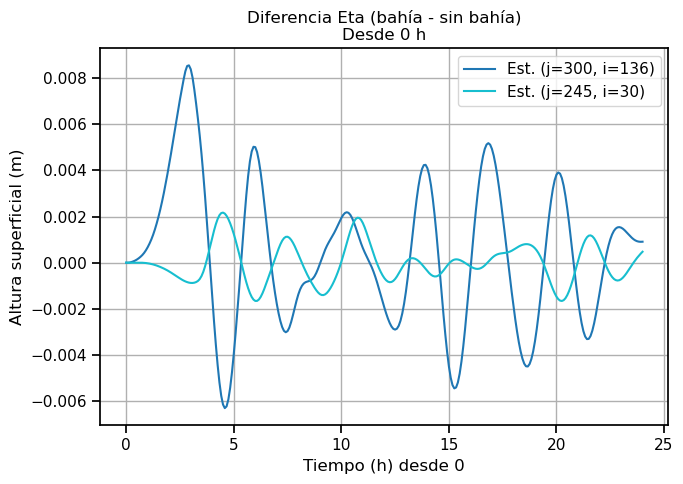

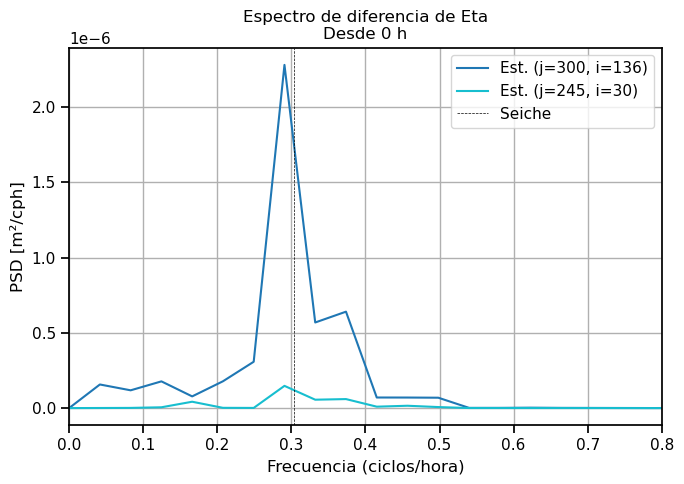

In [6]:
# Estaciones:
jstationA, istationA = 300, 136
jstationB, istationB = 245, 30

station_list = [
    (jstationA, istationA),
    (jstationB, istationB),
]

out = analizar_ssh_y_espectro_multistation(
         nc_bay, nc_nobay, time, station_list,
         tmin_horas=0,
         save_dir="../../Output_IWBay/",
         escenario_tag="linear",
         formato="npy"
)

## Seiche e IW espectro
 Estacion A: Seiche
 
 Estacion B: IW




In [9]:
def seiche_and_w_spc_multstation(nc_bay,nc_nobay, gr_bay,time,
                                 station_seiche,station_w, depth_target=-100,
                                 RC=None,
                                 tmin_horas=27.0):
    t = np.array(time, dtype=float)
    tmin_seg =tmin_horas * 3600
    idx_start = np.where(t >= tmin_seg) [0][0] if np.any(t >= tmin_seg) else 0
    
    #Recortamos el tiempo y convertimos a horas para graficar
    t_cut= t[idx_start:]
    dt= t_cut[0]-t_cut[1]
    t_cut_horas = t_cut / 3600.0
    
    plt.figure(figsize=(7,5))

    # Preparamos colores para cada estación (opcional)
    #colors = plt.cm.tab10(np.linspace(0, 1, len(2)))

    spectros= {}
    frec_cphs = None  # lo definiremos una sola vez (suponiendo que todas tienen mismo dt)

    j_ist_a,i_ist_a = station_seiche
    j_ist_b,i_ist_b = station_w
    
    #Valores de eta
    eta_bay = nc_bay.variables['Eta'][:,j_ist_a, i_ist_a]
    eta_nobay = nc_nobay.variables['Eta'][:,j_ist_a, i_ist_a]
    # 2) Convertir a numpy y recortar
    eta_b = np.array(eta_bay, dtype=float)
    eta_n = np.array(eta_nobay, dtype=float)
    eta_b_cut = eta_b[idx_start:]
    eta_n_cut = eta_n[idx_start:]
    eta_val = eta_b_cut- eta_n_cut
    eta_detrend= detrend(eta_val)

    #Valores de W
    if RC is None:
        RC = np.asarray(gr_bay.variables['RC'][:], float)

    # localiza el k más cercano a depth_target
    k = np.argmin(np.abs(RC - depth_target))
    w_bay = np.asarray(nc_bay.variables['W'][:,10,j_ist_b,i_ist_b], float)
    w_nobay = np.asarray(nc_nobay.variables['W'][:,10,j_ist_b,i_ist_b], float)
    w_b_cut = w_bay[idx_start:]
    w_n_cut = w_nobay[idx_start:]
    w_val= w_b_cut-w_n_cut
    w_detrend= detrend(w_val)

    # --- 4. FFT y PSD ---------------------------------------------------------
    def simple_psd(sig):
        N   = len(sig)
        Y   = np.fft.rfft(sig)
        f   = np.fft.rfftfreq(N, d=dt)           # [Hz]
        PSD = (np.abs(Y) / N)**2                 # potencia un-lateral
        return f, PSD
    f_eta, PSD_eta = simple_psd(eta_detrend)
    f_w, PSD_w = simple_psd(w_detrend)

    f_cph_eta = f_eta * 3600.0      # [ciclos/h]
    f_cph_w   = f_w   * 3600.0

    # Figura 1: Serie temporal
    plt.figure(figsize=(7, 5))
    plt.plot(t_cut_horas, eta_val,
              label= f'Est. (j={station_seiche[0]}, i={station_seiche[1]})')
    plt.plot(t_cut_horas, w_val,
             label= f'Est. (j={station_w[0]}, i={station_w[1]})')
    # --- Terminamos la figura de la serie temporal ---
    plt.xlabel('Tiempo (horas) desde ' + str(tmin_horas))
    plt.ylabel('Altura superficial (m)')
    plt.title(f'Diferencia Eta (bahía - sin bahía)\nDesde {tmin_horas} h')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Figura 2: Gráfico de espectros en la misma figura


    

<Figure size 700x500 with 0 Axes>

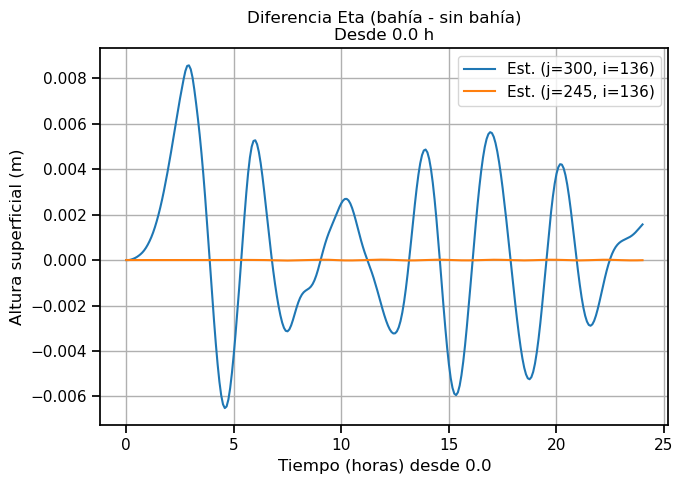

In [10]:
st_seiche= [300,136]
st_w = [245,136]

seiche_and_w_spc_multstation(nc_bay,nc_nobay, gr_bay,time,
                                 st_seiche,st_w, depth_target=-100,
                                 RC=None,
                                 tmin_horas=0.0)

In [28]:
RC = np.asarray(gr_bay.variables['RC'][:], float)
depth_target= -100
# localiza el k más cercano a depth_target
k = np.argmin(np.abs(RC - depth_target))

#j_ist_b= 245
#i_ist_b= 30
st_w= [245, 30]

tmin_horas= 2.5
# --- Convertimos el vector de tiempo a numpy y calculamos índice de corte ---
t = np.array(time, dtype=float)
tmin_seg = tmin_horas * 3600.0
# Índice donde comienza t >= tmin_seg
idx_start = np.where(t >= tmin_seg)[0][0] if np.any(t >= tmin_seg) else 0

w_100= nc_bay.variables['W'][idx_start:,k,st_w[0],st_w[1]]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import detrend

def analizar_ssh_y_w_espectro_multistation(nc_bay, 
    nc_nobay,
    grid_bay, 
    time, 
    station_seiche,
    station_w,
    depth_target=-100, # profundidad deseada para W  [m, negativa]
    RC=None,          # eje vertical RC (m, negativo). Si es None se toma de grid_bay
    tmin_horas=27.0):
     """
    Calcula y grafica la diferencia de altura superficial (Eta)
    entre configuraciones 'con bahía' y 'sin bahía' en varias estaciones,
    sobre la misma figura para la serie temporal y otra para la FFT.

    Parámetros
    ----------
    nc_bay : objeto netCDF (MITgcmutils)
        Contiene la variable 'Eta' para el caso con bahía.
    nc_nobay : objeto netCDF (MITgcmutils)
        Contiene la variable 'Eta' para el caso sin bahía.
    time : array-like
        Vector de tiempo, en segundos.
    station_list : list of tuples
        Lista de estaciones, cada una dada como (j_st, i_st).
        Ejemplo: [(300, 136), (305, 142)]
    tmin_horas : float
        Tiempo mínimo (en horas) a partir del cual se recorta la señal.
    """# --- Convertimos el vector de tiempo a numpy y calculamos índice de corte -t = np.array(time, dtype=float)
        tmin_seg = tmin_horas * 3600.0
        # Índice donde comienza t >= tmin_seg
        idx_start = np.where(t >= tmin_seg)[0][0] if np.any(t >= tmin_seg) else 0

        # Recortamos el tiempo y convertimos a horas para graficar
        t_cut = t[idx_start:]
        t_cut_horas = t_cut / 3600.0
     



    

 


    # --- 1. Recorte temporal --------------------------------------------------
    t      = np.asarray(time, dtype=float)
    tmin_s = tmin_horas * 3600.0
    idx0   = np.where(t >= tmin_s)[0][0] if np.any(t >= tmin_s) else 0
    t_cut  = t[idx0:]
    dt     = t_cut[1] - t_cut[0]          # [s] paso temporal
    fs     = 1.0 / dt                     # [Hz] frecuencia de muestreo

    # --- 2. Serie Eta ---------------------------------------------------------
    eta_vals = np.asarray(nc_eta.variables['Eta'][:, st_eta[0], st_eta[1]], float)
    eta_sig  = eta_vals[idx0:]
    eta_sig  = detrend(eta_sig)

    # --- 3. Serie W a ~100 m --------------------------------------------------
    if RC is None:
        RC = np.asarray(nc_w.variables['RC'][:], float)   # RC negativo hacia abajo

    # localiza el k más cercano a depth_target
    k = np.argmin(np.abs(RC - depth_target))
    w_vals = np.asarray(nc_w.variables['W'][:, k, st_w[0], st_w[1]], float)
    w_sig  = detrend(w_vals[idx0:])

    # --- 4. FFT y PSD ---------------------------------------------------------
    def simple_psd(sig):
        N   = len(sig)
        Y   = np.fft.rfft(sig)
        f   = np.fft.rfftfreq(N, d=dt)           # [Hz]
        PSD = (np.abs(Y) / N)**2                 # potencia un-lateral
        return f, PSD

    f_eta, PSD_eta = simple_psd(eta_sig)
    f_w,   PSD_w   = simple_psd(w_sig)

    f_cph_eta = f_eta * 3600.0      # [ciclos/h]
    f_cph_w   = f_w   * 3600.0

    # --- 5. Gráficas ----------------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

    # Serie temporal
    ax1.plot(t_cut/3600.0, eta_sig, label='η  (st A)', lw=1.1)
    ax1.plot(t_cut/3600.0, w_sig,   label='W 100 m (st B)', lw=1.1)
    ax1.set_ylabel('Amplitud (u. s.)')
    ax1.set_title(f'Series recortadas desde t = {tmin_horas} h')
    ax1.grid();  ax1.legend()

    # Espectro
    ax2.plot(f_cph_eta, PSD_eta, label='η  (st A)')
    ax2.plot(f_cph_w,   PSD_w,   label='W 100 m (st B)')
    ax2.axvline(0.303356, ls='--', lw=0.6, c='k', label='f seiche')
    ax2.set_xlim(0, 0.8)
    ax2.set_xlabel('Frecuencia (ciclos h⁻¹)')
    ax2.set_ylabel('PSD (u. s.² / cph)')
    ax2.set_title('Comparación espectral')
    ax2.grid();  ax2.legend()

    plt.tight_layout()
    plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cmocean as cmo



def plot_bathymetry_profile_by_j(gr, i=136, j_station=400):
    """
    Genera un perfil de la bahía a lo largo del eje j (filas),
    manteniendo fijo el índice i (columna).
    
    El eje X del gráfico se basa en la coordenada Y (YC[:, i]).
    Sin embargo, la ubicación de la estación se especifica con el índice
    j_station, y la función automáticamente dibuja la línea vertical
    en la coordenada Y correspondiente a YC[j_station, i].
    
    Parámetros
    ----------
    gr : objeto netCDF / MITgcmutils
        Contiene variables 'Depth', 'XC', 'YC' de la malla.
    i : int
        Índice de columna (i) donde se hace el corte a lo largo de j.
    j_station : int
        Índice de fila donde está la estación; se usará para trazar
        la línea vertical en el valor YC[j_station, i].
    """

    # Extraer variables
    depth = gr.variables['Depth'][:]  # shape ~ (ny, nx)
    XC = gr.variables['XC'][:]       # shape ~ (ny, nx)
    YC = gr.variables['YC'][:]       # shape ~ (ny, nx)

    # Perfil a lo largo de j, para la columna i
    Y_profile = YC[:, i]        # coordenada Y en cada fila
    Depth_profile = -depth[:, i] # profundidad (negativa para graficar hacia abajo)

    # Ubicación en Y de la estación, a partir de su índice j
    # (ojo que si j_station está fuera del rango [0, ny-1], habrá error)
    y_station = Y_profile[j_station]

    # Figura
    plt.figure(figsize=(8, 4))
    plt.plot(Y_profile, Depth_profile, label=f'Perfil en i={i}', color='blue')
    plt.xlabel('Coordenada Y')
    plt.ylabel('Profundidad (m)')
    plt.title(f'Perfil de la Bahía en i={i}')

    # Línea vertical en la ubicación de la estación
    plt.axvline(x=y_station, color='red', linestyle='--',
                label=f'Estación j={j_station}')
    
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



In [4]:
j_st_a = 252
i_st_a = 136
plot_bathymetry_profile_by_j(gr_bay, i=i_st_a, j_station=j_st_a)


NameError: name 'gr_bay' is not defined

In [ ]:
print('Profundidad en la estación:', gr_bay.variables['Depth'][j_st, i_st])

Profundidad en la estación: 166.9


In [ ]:
import numpy as np

def distance_between_stations(gr, j1, i1, j2, i2):
    """
    Calcula la distancia (en las mismas unidades que XC, YC) entre dos estaciones
    dadas por sus índices (j1, i1) y (j2, i2) en la malla de MITgcm.
    
    Parámetros
    ----------
    gr : objeto netCDF/MITgcmutils
        Contiene las variables 'XC' y 'YC'.
    j1, i1, j2, i2 : int
        Índices (j, i) de ambas estaciones.

    Retorna
    -------
    dist : float
        Distancia entre las dos estaciones, en las mismas unidades
        en que estén definidas XC y YC (habitualmente metros).
    """
    XC = gr.variables['XC'][:]
    YC = gr.variables['YC'][:]

    x1 = XC[j1, i1]
    y1 = YC[j1, i1]
    x2 = XC[j2, i2]
    y2 = YC[j2, i2]

    dist = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    return dist

# Ejemplo de uso:
jstationA, istationA = 252, 136
jstationB, istationB = 252, 75

dist_m = distance_between_stations(gr_bay, jstationA, istationA, jstationB, istationB)
print(f"La distancia entre las estaciones A y B es ~{dist_m:.2f} m")

# Si necesitas la distancia en km:
dist_km = dist_m / 1000.0
print(f"Distancia entre A y B en km: ~{dist_km:.3f} km")


La distancia entre las estaciones A y B es ~122514.75 m
Distancia entre A y B en km: ~122.515 km


## Densidad

In [6]:
XC = gr_bay.variables['XC'][0, :]
YC = gr_bay.variables['YC'][:, 0]
RC = gr_bay.variables['RC'][:]
hFacC = gr_bay.variables['HFacC'][:]
mask3D = np.ma.getmask(np.ma.masked_values(hFacC[:, :, :], 0))
EjeXBay = len(XC)//2

rho0 = 999.8
tAlpha = 2e-4
sBeta = 0
tRef = np.array([16.6, 16.6, 16.6, 16.6, 16.6, 16.55, 16.5, 16.5, 16.5, 16.5, 
	16.5, 16.5, 16.5, 16.5, 16.5, 16.5, 16.45, 16.4, 16.4, 16.34, 
	16.25, 16.1, 15.96, 15.82, 15.64, 15.35, 15.0, 14.61, 14.15, 13.64, 
	13.01, 12.34, 11.66, 11.14, 10.67, 10.18, 9.66, 9.28, 8.96, 8.66, 
	8.35, 8.04, 7.67, 7.33, 7.02, 6.7, 6.47, 6.24, 6.01, 5.77,])  # reemplaza con tus valores del archivo data
sRef = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
	0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
	0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
	0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
	0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,])  # reemplaza con tus valores del archivo data

W_bay_init = nc_bay.variables['W'][0, :, :, EjeXBay]
T_init = nc_bay.variables['Temp'][0, :, :, EjeXBay]
tRef[:]=4
S_init = nc_bay.variables['S'][0, :, :, EjeXBay]


In [7]:
# Densidad inicial constante para toda la animación
rho_init = rho0 * (1 - tAlpha*(T_init - tRef[:, None]))

In [8]:
rhomin= np.min(rho_init)
rhomax= np.max(rho_init)
print(rhomin)

993.886399


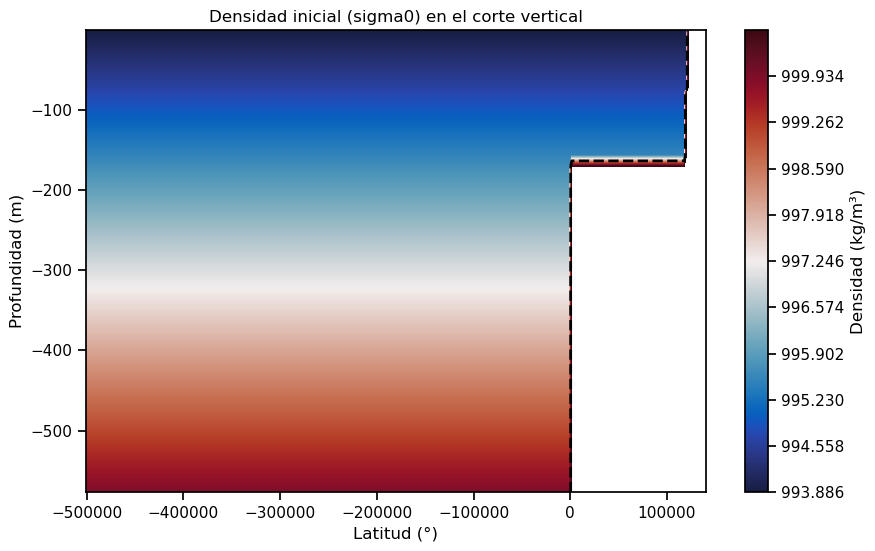

In [9]:
#graficar el perfil de densidad inicial
plt.figure(figsize=(10, 6))
plt.contourf(
    YC,
    RC,
    rho_init,
    levels= np.arange(rhomin, rhomax, 0.001,),
    cmap=cmo.cm.balance,
)
plt.colorbar(label='Densidad (kg/m³)')
plt.title('Densidad inicial (sigma0) en el corte vertical') 
plt.xlabel('Latitud (°)')
plt.ylabel('Profundidad (m)')
plt.contour(
    YC,
    RC,
    mask3D[:, :, EjeXBay],
    colors='black',
    linewidths=2,
    linestyles='--'
)
plt.show()

In [10]:
print(np.min(rho_init))
print(np.max(rho_init))

993.886399
1000.5998399999999


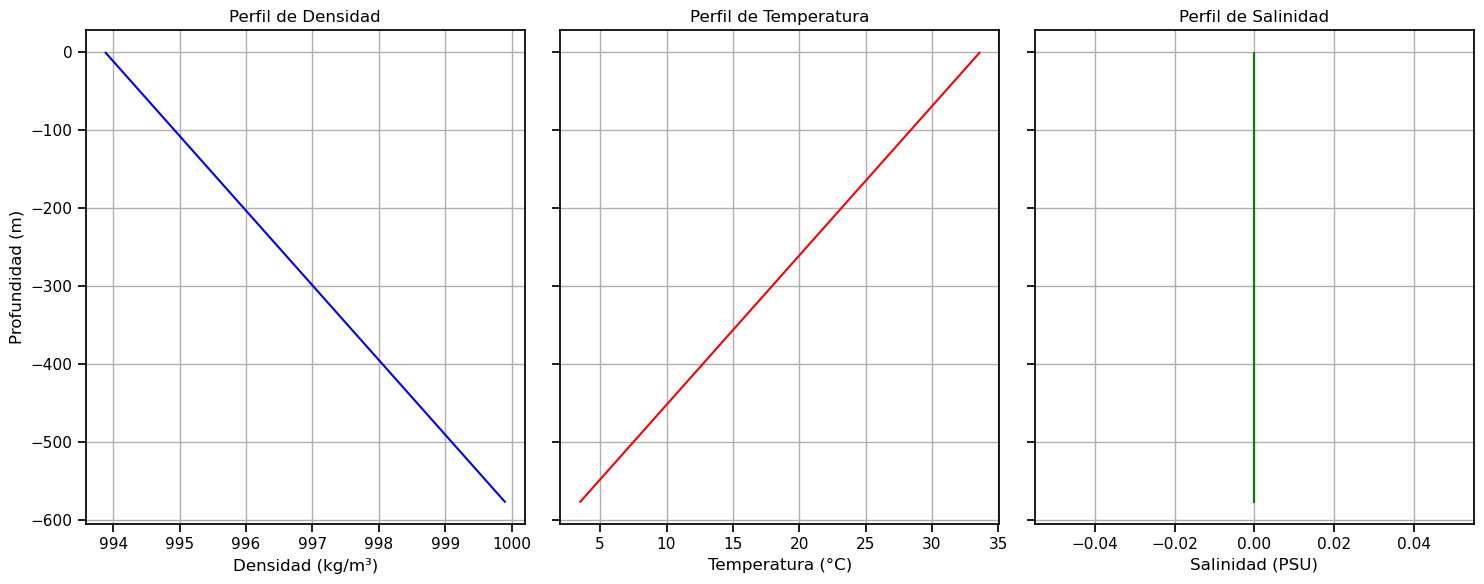

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

# Subplot 1: Density
axes[0].plot(rho_init[:, 2], RC, color='blue', label='Densidad')
axes[0].set_xlabel('Densidad (kg/m³)')
axes[0].set_ylabel('Profundidad (m)')
axes[0].set_title('Perfil de Densidad')
axes[0].grid()

# Subplot 2: Temperature
axes[1].plot(T_init[:, 2], RC, color='red', label='Temperatura')
axes[1].set_xlabel('Temperatura (°C)')
axes[1].set_title('Perfil de Temperatura')
axes[1].grid()

# Subplot 3: Salinity
axes[2].plot(S_init[:, 2], RC, color='green', label='Salinidad')
axes[2].set_xlabel('Salinidad (PSU)')
axes[2].set_title('Perfil de Salinidad')
axes[2].grid()

# Adjust layout
plt.tight_layout()
plt.show()

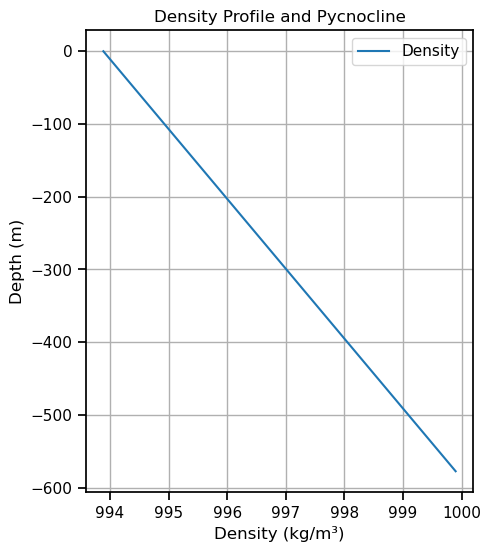

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Suppose that:
# - rho_profile is your density profile rho_init[:, 2]
# - RC is your depth vector (must have the same length as rho_profile)

rho_profile = rho_init[:, 2]
z = RC  # usually negative, by oceanographic convention

# Calculate the vertical derivative of the density
drho_dz = np.gradient(rho_profile, z)

# Find the index where the gradient has the maximum magnitude
pycnocline_idx = np.argmax(np.abs(drho_dz))
z_pycnocline = z[pycnocline_idx]
rho_pycnocline = rho_profile[pycnocline_idx]

# Visualization
plt.figure(figsize=(5, 6))
plt.plot(rho_profile, z, label='Density')
#plt.axhline(z_pycnocline, color='r', linestyle='--', label='Pycnocline')
#plt.gca().invert_yaxis()
plt.xlabel('Density (kg/m³)')
plt.ylabel('Depth (m)')
plt.legend()
plt.title('Density Profile and Pycnocline')
plt.grid()
plt.show()


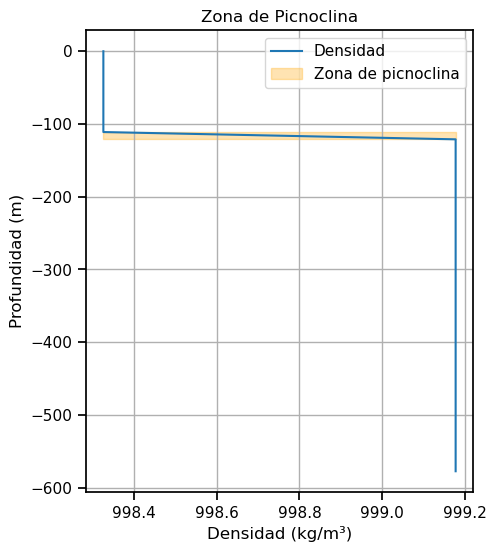

Picnoclina entre -111.40 m y -121.40 m


In [15]:
# Densidad y profundidad
rho_profile = rho_init[:, 2]
z = RC  # ojo, en MITgcm normalmente es negativo

# Gradiente vertical de densidad
drho_dz = np.gradient(rho_profile, z)

# Umbral: 50% del valor máximo de |drho_dz|
threshold = 0.40 * np.max(np.abs(drho_dz))

# Índices donde el gradiente supera el umbral
picnoclina_mask = np.abs(drho_dz) > threshold

# Encontrar rango de profundidades
if np.any(picnoclina_mask):
    indices = np.where(picnoclina_mask)[0]
    z_start = z[indices[0]]
    z_end = z[indices[-1]]
else:
    z_start = z_end = np.nan  # No hay picnoclina detectable

# Plot
plt.figure(figsize=(5, 6))
plt.plot(rho_profile, z, label='Densidad')
plt.fill_betweenx(z, np.min(rho_profile), np.max(rho_profile), 
                  where=picnoclina_mask, color='orange', alpha=0.3, label='Zona de picnoclina')
plt.xlabel('Densidad (kg/m³)')
plt.ylabel('Profundidad (m)')
plt.title('Zona de Picnoclina')
plt.legend()
plt.grid()
plt.show()

print(f"Picnoclina entre {z_start:.2f} m y {z_end:.2f} m")


## Diagrama de hovmoller en Estaciones

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import cmocean as cmo
from matplotlib.colors import TwoSlopeNorm

def hovmoller_station(
        nc_bay,
        gr,
        station,
        varname='W',
        subtract=False,
        nc_nobay=None,
        cmap=cmo.cm.balance,
        vmin=None, vmax=None,
        hours_offset=0.0,
        title_suffix=''
):
    j, i = station
    t_all = nc_bay.variables['T'][:] / 3600.0
    RC    = gr.variables['RC'][:]
    idx0  = np.where(t_all >= hours_offset)[0][0] if hours_offset>0 else 0
    t     = t_all[idx0:]

    data_bay = nc_bay.variables[varname][:, :, j, i]
    if subtract:
        if nc_nobay is None:
            raise ValueError("nc_nobay es obligatorio cuando subtract=True")
        data = data_bay - nc_nobay.variables[varname][:, :, j, i]
    else:
        data = data_bay
    data = data[idx0:, :]

    # Límites de color
    if vmin is None or vmax is None:
        vmax = np.nanmax(data)
        vmin = np.nanmin(data)
    norm = None
    if vmin < 0 and vmax > 0:
        norm = TwoSlopeNorm(vcenter=0., vmin=vmin, vmax=vmax)

    # Figura
    fig, ax = plt.subplots(figsize=(9, 5))
    if norm is None:
        mesh = ax.pcolormesh(t, RC, data.T, cmap=cmap,
                             vmin=vmin, vmax=vmax, shading='auto')
    else:
        mesh = ax.pcolormesh(t, RC, data.T, cmap=cmap,
                             norm=norm, shading='auto')
    fig.colorbar(mesh, ax=ax, label=f'{varname} (unid.)')
    ax.set_xlabel('Tiempo (h)')
    ax.set_ylabel('Profundidad (m)')
    ax.set_title(f'Hovmöller {varname}  Estación (j={j}, i={i}) {title_suffix}')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


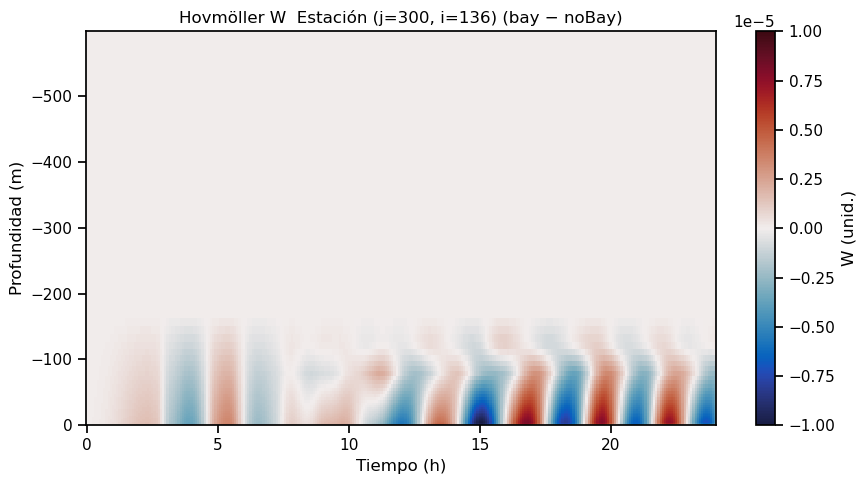

In [17]:
# -- Estación A --------------------------------------------------------------
hovmoller_station(
    nc_bay, gr_bay,
    station=(300, 136),
    varname='W',
    subtract=True,
    nc_nobay=nc_nobay,
    vmin=-1e-5, vmax=1e-5,
    title_suffix='(bay − noBay)'
)



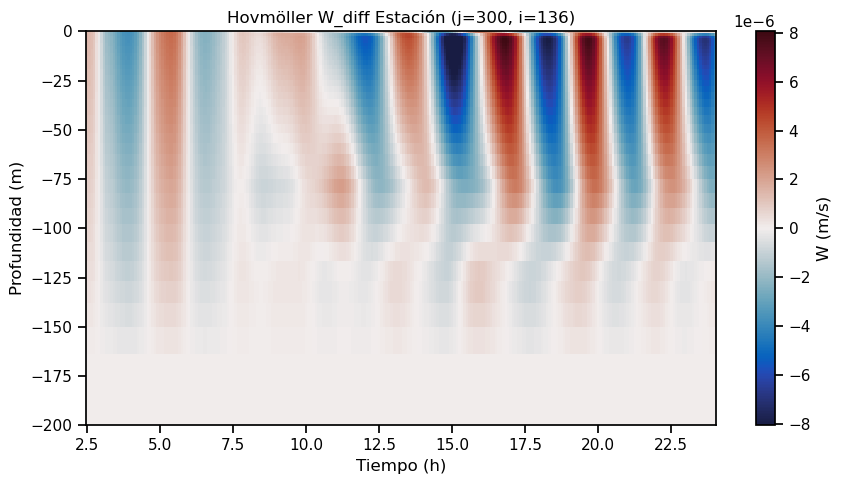

In [18]:
station=(300, 136)
j, i = station
hours_offset = 2.5
t_all = nc_bay.variables['T'][:] / 3600.0
RC    = gr_bay.variables['RC'][:]
idx0  = np.where(t_all >= hours_offset)[0][0] if hours_offset>0 else 0
t     = t_all[idx0:]

W_bay = nc_bay.variables['W'][:, :, j, i]
W_nobay = nc_nobay.variables['W'][:, :, j, i]
W_diff = W_bay - W_nobay
W_diff = W_diff[idx0:, :]
vmax = np.nanmax(W_diff)
vmin = -vmax

fig, ax = plt.subplots(figsize=(9, 5))

mesh = ax.pcolormesh(
    t,                     # eje X (tiempo)
    RC,                    # eje Y (profundidad)
    W_diff.T,              # (z, t)  ⇒  (len(RC), len(t))
    cmap=cmo.cm.balance,
    vmin=vmin, vmax=vmax,
    shading='auto'         # <‑‑ evita el error de dimensiones
)

fig.colorbar(mesh, ax=ax, label='W (m/s)')
ax.set_xlabel('Tiempo (h)')
ax.set_ylabel('Profundidad (m)')
ax.set_title(f'Hovmöller W_diff Estación (j={j}, i={i})')  
plt.ylim(-200, 0)     
plt.tight_layout()
plt.show()

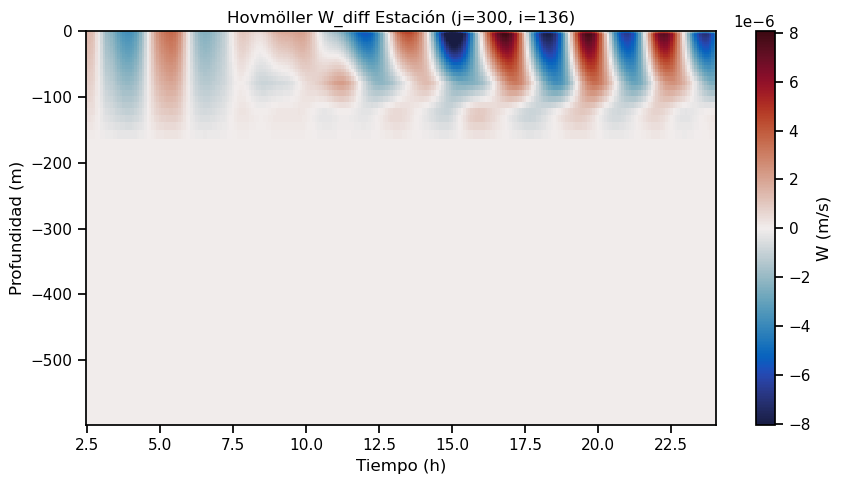

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))

mesh = ax.pcolormesh(
    t,                     # eje X (tiempo)
    RC,                    # eje Y (profundidad)
    W_diff.T,              # (z, t)  ⇒  (len(RC), len(t))
    cmap=cmo.cm.balance,
    vmin=vmin, vmax=vmax,
    shading='auto'         # <‑‑ evita el error de dimensiones
)

fig.colorbar(mesh, ax=ax, label='W (m/s)')
ax.set_xlabel('Tiempo (h)')
ax.set_ylabel('Profundidad (m)')
ax.set_title(f'Hovmöller W_diff Estación (j={j}, i={i})')       
plt.tight_layout()
plt.show()


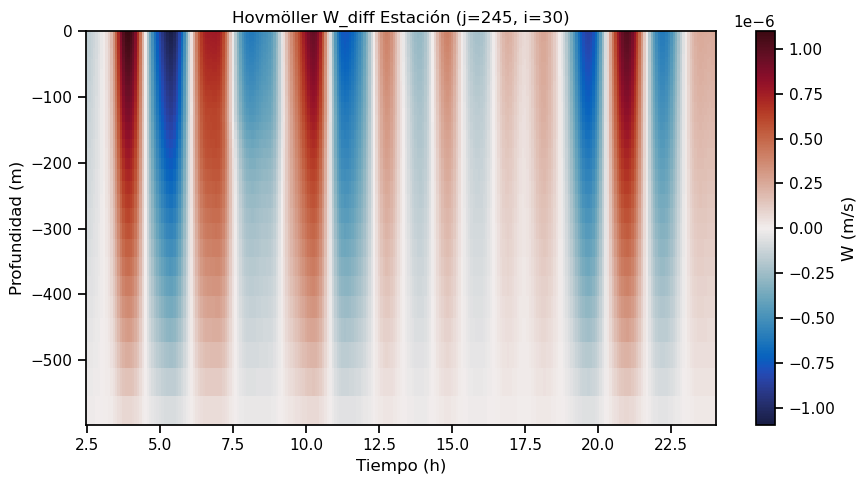

In [20]:
station=(245, 30)
j, i = station
hours_offset = 2.5
t_all = nc_bay.variables['T'][:] / 3600.0
RC    = gr_bay.variables['RC'][:]
idx0  = np.where(t_all >= hours_offset)[0][0] if hours_offset>0 else 0
t     = t_all[idx0:]

W_bay = nc_bay.variables['W'][:, :, j, i]
W_nobay = nc_nobay.variables['W'][:, :, j, i]
W_diff = W_bay - W_nobay
W_diff = W_diff[idx0:, :]
vmax = np.nanmax(W_diff)
vmin = -vmax

fig, ax = plt.subplots(figsize=(9, 5))

mesh = ax.pcolormesh(
    t,                     # eje X (tiempo)
    RC,                    # eje Y (profundidad)
    W_diff.T,              # (z, t)  ⇒  (len(RC), len(t))
    cmap=cmo.cm.balance,
    vmin=vmin, vmax=vmax,
    shading='auto'         # <‑‑ evita el error de dimensiones
)

fig.colorbar(mesh, ax=ax, label='W (m/s)')
ax.set_xlabel('Tiempo (h)')
ax.set_ylabel('Profundidad (m)')
ax.set_title(f'Hovmöller W_diff Estación (j={j}, i={i})')       
plt.tight_layout()
plt.show()


In [21]:
import numpy as np
import matplotlib.pyplot as plt
import cmocean as cmo

def hovmoller_diff(
        nc_bay,
        nc_nobay,
        gr,
        station,
        varname='W',
        hours_offset=0.0,
        cmap=cmo.cm.balance,
        vmin=None,
        vmax=None,
        title_prefix=''
):
    """
    Diagrama de Hovmöller de la diferencia (bahía – sin bahía)
    en una estación puntual.

    Parámetros
    ----------
    nc_bay      : dataset MITgcm con la simulación con bahía.
    nc_nobay    : dataset MITgcm con la simulación sin bahía.
    gr          : dataset de malla (para RC).
    station     : tuple (j, i) índices de la estación.
    varname     : str   nombre de la variable 3‑D (default 'W').
    hours_offset: float horas a descartar al inicio (spin‑up).
    cmap        : matplotlib colormap.
    vmin, vmax  : límites de la escala; si uno es None se calcula automático
                 y se hace simétrico alrededor de 0.
    title_prefix: str   texto adicional para el título.
    """

    # ------------- 1. Índices y recorte en tiempo --------------------------------
    j, i = station
    t_all  = nc_bay.variables['T'][:] / 3600.0               # a horas
    idx0   = np.where(t_all >= hours_offset)[0][0] if hours_offset > 0 else 0
    t      = t_all[idx0:]

    # ------------- 2. Serie de la variable en la estación -------------------------
    data_bay   = nc_bay.variables[varname][:, :, j, i]       # (time, z)
    data_nobay = nc_nobay.variables[varname][:, :, j, i]
    data_diff  = data_bay - data_nobay                      # (time, z)
    data_diff  = data_diff[idx0:, :]                        # recorte temporal

    # ------------- 3. Límites de color -------------------------------------------
    if vmin is None or vmax is None:
        vmax = np.nanmax(data_diff)
        vmin = -vmax

    # ------------- 4. Figura ------------------------------------------------------
    RC  = gr.variables['RC'][:]                             # profundidad (negativa)
    fig, ax = plt.subplots(figsize=(9, 5))

    mesh = ax.pcolormesh(
        t,                     # eje X (tiempo)
        RC,                    # eje Y (profundidad)
        data_diff.T,           # (z, t)
        cmap=cmap,
        vmin=vmin, vmax=vmax,
        shading='auto'
    )

    fig.colorbar(mesh, ax=ax, label=f'{varname} (unidades)')
    ax.set_xlabel('Tiempo (h)')
    ax.set_ylabel('Profundidad (m)')
    ax.set_title(f'{title_prefix} Hovmöller {varname}_diff  Estación (j={j}, i={i})')
    ax.invert_yaxis()    # profundidad hacia abajo
    plt.tight_layout()
    plt.show()

    return fig, ax


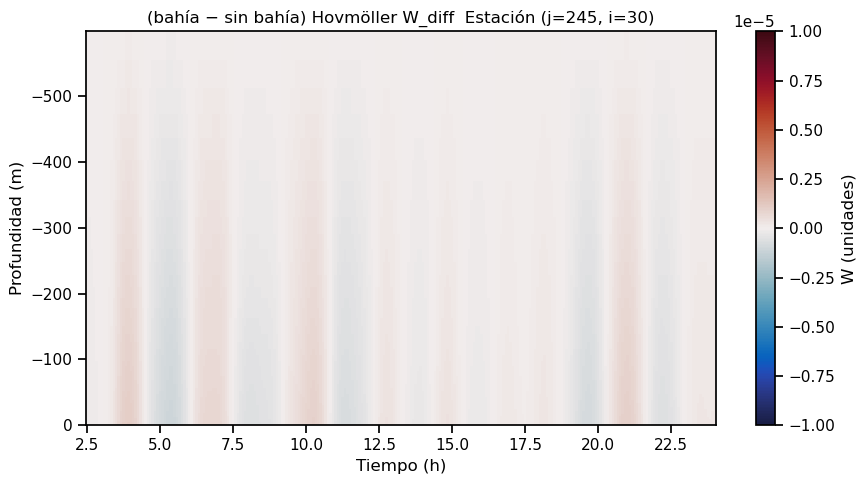

(<Figure size 900x500 with 2 Axes>,
 <Axes: title={'center': '(bahía − sin bahía) Hovmöller W_diff  Estación (j=245, i=30)'}, xlabel='Tiempo (h)', ylabel='Profundidad (m)'>)

In [22]:
# Estación B, variable W, quitando las primeras 2.5 h de spin‑up
hovmoller_diff(
    nc_bay, nc_nobay, gr_bay,
    station=(245, 30),
    varname='W',
    hours_offset=2.5,
    vmin=-1e-5, vmax=1e-5,
    title_prefix='(bahía − sin bahía)'
)


## Energia cinética

In [ ]:
import numpy as np

# ───── Interpolación coherente a centros de celda ───────────────────────────
def unstagger_uv(ugrid, vgrid):
    """
    Interpola U (en X-faces) y V (en Y-faces) al centro de cada celda.

      ugrid : (t,z, y ,xp1)
      vgrid : (t,z, yp1,x)

    Devuelve u, v con shape idéntica (t,z, y , x)
    """
    # 1) U: promedio entre pares adyacentes en X
    u = 0.5 * (ugrid[..., :-1] + ugrid[..., 1:])          # (t,z,y,x)

    # 2) V: promedio entre pares adyacentes en Y
    v = 0.5 * (vgrid[..., :-1, :] + vgrid[..., 1:, :])    # (t,z,y,x)

    return u, v                                           # mismas dims

def unstagger_w(wgrid):
    """
    Interpola W (en Z-faces) al centro de la celda vertical.

      wgrid : (t, zp1 ,y,x)
    Devuelve w : (t, z ,y,x)  donde z = zp1-1
    """
    return 0.5*(wgrid[:, :-1, ...] + wgrid[:, 1:, ...])   # (t,z,y,x)

# ───── Función principal con opción diff=True ──────────────────────────────
def energia_cinetica_dominio(
        nc_a, nc_grid,
        nc_b=None,              # segundo run para restar
        diff=False,             # True → usa (a-b)
        rho0=1025.0,
        chunk=24
    ):
    """
    Energía cinética total (J) en cada salida temporal.
      diff=False → KE de nc_a
      diff=True  → KE de (nc_a − nc_b)
    """
    # --- métricas ----------------------------------------------------------
    def _get(names, label):
        for n in names:
            if n in nc_grid.variables:
                return np.asarray(nc_grid.variables[n][:])
        raise KeyError(f"Falta {label} en nc_grid.")

    try:
        RAC = _get(['RAC','rA'], 'RAC')                       # (y,x)
    except KeyError:
        DXC = _get(['DXC','dxC'], 'DXC')
        DYC = _get(['DYC','dyC'], 'DYC')
        RAC = DXC * DYC                                       # (y,x)

    DRF   = _get(['DRF','drF'], 'DRF')                        # (z)
    hFacC = _get(['HFacC','hFacC'], 'hFacC')                  # (z,y,x)
    dV    = DRF[:,None,None] * RAC[None,:,:] * hFacC          # (z,y,x)

    if diff and nc_b is None:
        raise ValueError("diff=True → debes pasar nc_b")

    nt = nc_a.variables['T'].shape[0]
    ke = np.empty(nt)

    for s in range(0, nt, chunk):
        e = min(nt, s+chunk)

        # leer U,V,W bloque t=s:e
        Ua, Va, Wa = (nc_a.variables['U'][s:e],
                      nc_a.variables['V'][s:e],
                      nc_a.variables['W'][s:e])

        if diff:
            Ua -= nc_b.variables['U'][s:e]
            Va -= nc_b.variables['V'][s:e]
            Wa -= nc_b.variables['W'][s:e]

        Uc, Vc = unstagger_uv(Ua, Va)            # (t,50,y,x)
        Wc     = unstagger_w(Wa)                 # (t,49,y,x)

        nz = Wc.shape[1]
        nz = 10                         # niveles válidos = 49
        # ► igualamos dimensiones en z
        Uc = Uc[:, :nz, ...]
        Vc = Vc[:, :nz, ...]
        dVw = dV[:nz, ...]                       # volumen con 49 niveles
        Wc= Wc[:,:nz,...]

        speed2 = Uc**2 + Vc**2 + Wc**2           # asegura mismo z

        rho0 = rho0 * np.ones_like(speed2)      # densidad constante

        #speed2 = Uc**2 + Vc**2 + Wc**2
        ke[s:e] = 0.5*rho0 * np.tensordot(speed2, dVw,
                                          axes=([1,2,3],[0,1,2]))
        np.save(file='ke_2layer',ke)

    return ke


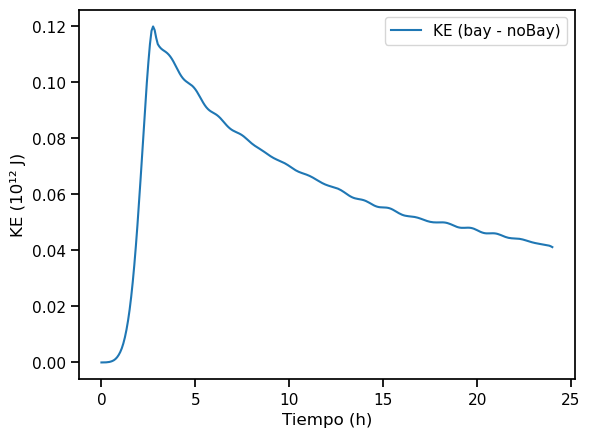

In [15]:
# 1) Energía absoluta del run con bahía
#ke_bay = energia_cinetica_dominio(nc_bay, gr_bay)

# 2) Energía de la “señal” bahía − sin bahía
ke_diff = energia_cinetica_dominio(
    nc_bay, gr_bay,
    nc_b=nc_nobay,
    diff=True
)

# graficar
import matplotlib.pyplot as plt
plt.plot(time/3600, ke_diff/1e12, label='KE (bay - noBay)')
plt.xlabel('Tiempo (h)'); plt.ylabel('KE (10¹² J)')
plt.legend(); plt.show()


In [ ]:
try:
        RAC = _get(['RAC','rA'], 'RAC')                       # (y,x)
    except KeyError:
        DXC = _get(['DXC','dxC'], 'DXC')
        DYC = _get(['DYC','dyC'], 'DYC')
        RAC = DXC * DYC                                       # (y,x)

    DRF   = _get(['DRF','drF'], 'DRF')                        # (z)
    hFacC = _get(['HFacC','hFacC'], 'hFacC')                  # (z,y,x)
    dV    = DRF[:,None,None] * RAC[None,:,:] * hFacC          # (z,y,x)

In [4]:
import numpy as np
import os


# ─────────── Helper: interpolate velocity components to cell centres ──────────
def unstagger_uv(ugrid, vgrid):
    """
    Interpolate U (on x-faces) and V (on y-faces) to cell centres.

      ugrid : (t, z, y , xp1)
      vgrid : (t, z, yp1, x)

    Returns
    -------
    u, v : (t, z, y, x)   # same shape, centred fields
    """
    u = 0.5 * (ugrid[..., :-1] + ugrid[..., 1:])        # (t,z,y,x)
    v = 0.5 * (vgrid[..., :-1, :] + vgrid[..., 1:, :])  # (t,z,y,x)
    return u, v


def unstagger_w(wgrid):
    """
    Interpolate W (on z-faces) to the vertical centre of each cell.

      wgrid : (t, zp1, y, x)

    Returns
    -------
    w : (t, z, y, x)   # z = zp1-1
    """
    return 0.5 * (wgrid[:, :-1, ...] + wgrid[:, 1:, ...])


# ───────────────────────────── Main routine ───────────────────────────────────
def kinetic_energy_timeseries(
        time,               # time axis (1D)
        nc_a, nc_grid,
        nc_b=None,                       # second run to subtract (optional)
        diff=False,                      # if True: use (a – b)
        scenario_tag="2layer",             # filename prefix when saving
        x_index_for_T=0,                 # column used to extract T_init
        t_ref_value=4.0,                 # °C reference temperature
        rho0=999.8,                      # reference density  (kg m-3)
        t_alpha=2e-4,                    # thermal expansion (°C-1)
        chunk=24,                        # number of time steps per block
        out_dir="./",                     # where to save *.npy

    ):
    """
    Compute the total kinetic energy (J) at each model output time.

    Parameters
    ----------
    nc_a, nc_b : netCDF4.Dataset
        MITgcm output files containing U, V, W, Temp.
    nc_grid    : netCDF4.Dataset
        MITgcm grid file with metrics (RAC, DRF, HFacC, …).
    diff       : bool
        False → KE of nc_a only.
        True  → KE of (nc_a – nc_b).
    scenario_tag : str
        Used in the output filename  'KE_<tag>.npy'.
    x_index_for_T : int
        Selected i-index to grab the initial temperature profile.
    t_ref_value : float
        Reference temperature for the density formula  ρ = ρ0 [1-α(T-Tref)].
    """

    # ── 1. Grid metrics (areas, layer thickness, wet mask) ───────────────────
    def _get(names, label):
        for n in names:
            if n in nc_grid.variables:
                return np.asarray(nc_grid.variables[n][:])
        raise KeyError(f"{label} not found in grid file.")

    try:
        RAC = _get(['RAC', 'rA'], 'RAC')                    # (y, x) cell area
    except KeyError:
        DXC = _get(['DXC', 'dxC'], 'DXC')
        DYC = _get(['DYC', 'dyC'], 'DYC')
        RAC = DXC * DYC                                     # fallback

    DRF   = _get(['DRF', 'drF'], 'DRF')                     # (z)
    HFacC = _get(['HFacC', 'hFacC'], 'HFacC')               # (z,y,x)
    dV    = DRF[:, None, None] * RAC[None, :, :] * HFacC    # (z,y,x) cell vol

    if diff and nc_b is None:
        raise ValueError("diff=True requires 'nc_b' to be provided.")

    # ── 2. Build static density field from the *initial* temperature profile ─
    #      shape: (z, y, x)  — we broadcast across x with the chosen column
    T_init = nc_a.variables['Temp'][0, :, :, x_index_for_T]        # (z, y)
    T_ref  = np.full_like(T_init, t_ref_value)                     # (z, y)
    rho_init = rho0 * (1.0 - t_alpha * (T_init - T_ref))           # (z, y)
    rho_init = rho_init[:, :, None]                                # (z, y, 1)
    rho_init = np.broadcast_to(rho_init, dV.shape)                 # (z,y,x)

    # ── 3. Time loop in chunks ───────────────────────────────────────────────
    nt = time.shape[0]
    KE = np.empty(nt)

    HFacC = nc_grid.variables['HFacC'][:10,:,:]               # (z,y,x)
    # Boolean mask: True = land/blocked
    wet_mask = HFacC == 0.0

    for s in range(0, nt, chunk):
        e = min(nt, s + chunk)

        Ua = nc_a.variables['U'][s:e]
        Va = nc_a.variables['V'][s:e]
        Wa = nc_a.variables['W'][s:e]

        if diff:
            Ua = Ua - nc_b.variables['U'][s:e]
            Va = Va - nc_b.variables['V'][s:e]
            Wa = Wa - nc_b.variables['W'][s:e]

        Uc, Vc = unstagger_uv(Ua, Va)      # (t, z, y, x)
        Wc     = unstagger_w(Wa)           # (t, z, y, x)

        # ensure the same vertical extent
        #nz = min(Uc.shape[1], Wc.shape[1], dV.shape[0])
        nz = 10                         # valid levels = 49
        Uc = Uc[:, :nz]
        Vc = Vc[:, :nz]
        Wc = Wc[:, :nz]
        dV_block   = dV[:nz]
        rho_block  = rho_init[:nz]

        speed2 = Uc**2 + Vc**2 + Wc**2     # (t,z,y,x)
        #speed2[..., wet_mask] = np.nan    # mask out land/blocked cells

        # KE(t) = ½ ∑ ρ |u|² dV
        KE[s:e] = 0.5 * np.tensordot(speed2 * rho_block,  dV_block,
                                      axes=([1, 2, 3], [0, 1, 2]))

    # ── 4. Save and return ──────────────────────────────────────────────────
    fname = os.path.join(out_dir, f"KE_{scenario_tag}.npy")
    np.save(fname, KE)
    print(f"[INFO] kinetic-energy series saved to {fname}")

    return KE


In [5]:
kinetic_energy_timeseries(
        time,
        nc_bay, gr_bay,            # run with bay
        nc_nobay,                       # second run to subtract (optional)
        diff=True,                      # if True: use (a – b)
        scenario_tag="linear",             # filename prefix when saving
        x_index_for_T=0,                 # column used to extract T_init
        t_ref_value=4.0,                 # °C reference temperature
        rho0=999.8,                      # reference density  (kg m-3)
        t_alpha=2e-4,                    # thermal expansion (°C-1)
        chunk=24,                        # number of time steps per block
        out_dir="/Volumes/Esteban_SSD/Maestría/MITgcm/verification/Output_IWBay/",                     # where to save *.npy  

    )

[INFO] kinetic-energy series saved to /Volumes/Esteban_SSD/Maestría/MITgcm/verification/Output_IWBay/KE_linear.npy


array([0.00000000e+00, 2.26553604e+06, 1.23122604e+07, 3.63377411e+07,
       8.52349447e+07, 1.71439671e+08, 3.08156062e+08, 5.08488378e+08,
       7.95501379e+08, 1.21545070e+09, 1.80232860e+09, 2.58908915e+09,
       3.60543950e+09, 4.91773090e+09, 6.61604556e+09, 8.75705639e+09,
       1.13910797e+10, 1.45586777e+10, 1.83426441e+10, 2.28095021e+10,
       2.79913209e+10, 3.39018553e+10, 4.05293799e+10, 4.77856433e+10,
       5.55795197e+10, 6.38097097e+10, 7.23592626e+10, 8.10524043e+10,
       8.94972430e+10, 9.74327771e+10, 1.04635060e+11, 1.10909367e+11,
       1.15533134e+11, 1.17047567e+11, 1.15773218e+11, 1.13003820e+11,
       1.10828429e+11, 1.09945787e+11, 1.09282961e+11, 1.08790808e+11,
       1.08388402e+11, 1.07994210e+11, 1.07540372e+11, 1.06981411e+11,
       1.06294992e+11, 1.05478421e+11, 1.04545366e+11, 1.03524341e+11,
       1.02458503e+11, 1.01402822e+11, 1.00415459e+11, 9.95455346e+10,
       9.88218244e+10, 9.82463350e+10, 9.77950552e+10, 9.74248992e+10,
      

## Espectro velocidad vertical w

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import detrend
import os


def analizar_w_y_espectro_dosprof(
        nc_bay,
        nc_nobay,
        time,
        j_i_station,                # (j, i)  -- una sola estación
        depth_levels,               # [100, 400]   (m)  o índices verticales
        *,
        tmin_horas=0.0,
        save_dir=None,
        escenario_tag="escenario",
        formato="npz",
        var_name="W",               # nombre de la variable en los netCDF
        depth_coord_name="Z"        # eje vertical (MITgcm suele ser 'Z')
):
    """
    Diferencia vertical-velocity (W_bay - W_nobay) en dos profundidades y su FFT.

    Parámetros (idéntico espíritu al anterior):
    -------------------------------------------
    nc_bay / nc_nobay :  archivos MITgcm (netCDF) con la variable `W`.
    time             :  vector temporal (segundos).
    j_i_station      :  tupla (j, i) de la celda a analizar.
    depth_levels     :  lista con EXACTAMENTE dos profundidades deseadas.
                        • si son positivas: se asumen |z| [m] y se busca el
                          nivel más cercano;
                        • si son enteros >=0 : se toman como índices directos.
    save_dir / escenario_tag / formato :  control de salida en disco.
    """

    # -------------- Tiempo -----------------
    t = np.asarray(time, float)
    idx0 = np.where(t >= tmin_horas * 3600)[0][0] if np.any(t >= tmin_horas * 3600) else 0
    t_cut, t_h = t[idx0:], t[idx0:] / 3600.0

    # -------------- Profundidades ----------
    z_vals = np.asarray(nc_bay.variables[depth_coord_name][:])
    z_dim  = len(z_vals)

    dep_idx = []
    dep_lbl = []
    for d in depth_levels:
        if isinstance(d, int) and 0 <= d < z_dim:
            dep_idx.append(d)
        else:            # profundidad física (m)
            k = int(np.argmin(np.abs(z_vals + abs(d))))
            dep_idx.append(k)
        dep_lbl.append(f"{abs(z_vals[dep_idx[-1]]):.0f} m")

    if len(dep_idx) != 2:
        raise ValueError("depth_levels must contain exactly two levels")

    colores = ["tab:blue", "tab:red"]
    espectros = {}

    # --------- Figura: serie temporal -------
    plt.figure(figsize=(7, 4))
    for k, (kz, col) in enumerate(zip(dep_idx, colores)):
        w_b = nc_bay.variables[var_name][:, kz, j_i_station[0], j_i_station[1]].astype(float)
        w_n = nc_nobay.variables[var_name][:, kz, j_i_station[0], j_i_station[1]].astype(float)

        w_diff = w_b[idx0:] - w_n[idx0:]      # diferencia bahía – sin bahía
        plt.plot(t_h, w_diff, color=col, lw=1.2, label=dep_lbl[k])

        # --------------- FFT -----------------
        w_dt = detrend(w_diff)
        dt   = t_cut[1] - t_cut[0] if len(t_cut) > 1 else 1.0
        N    = len(w_dt)
        freqs = np.fft.rfftfreq(N, dt)
        PSD   = (np.abs(np.fft.rfft(w_dt))**2) / N**2
        espectros[kz] = (freqs * 3600., PSD)   # cph

        # ------------- Guardar ---------------
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
            fn = os.path.join(save_dir,
                              f"{escenario_tag}_Wdiff_{int(abs(z_vals[kz]))}m.{formato}")
            if formato == "npz":
                np.savez_compressed(fn,
                                    t_h=t_h, Wdiff=w_diff,
                                    freq_cph=espectros[kz][0], PSD=espectros[kz][1])
            elif formato == "npy":
                np.save(fn,
                        {"t_h": t_h,
                         "Wdiff": w_diff,
                         "freq_cph": espectros[kz][0],
                         "PSD": espectros[kz][1]})
            else:
                raise ValueError("formato debe ser 'npz' o 'npy'")

    plt.xlabel("Tiempo (h)")
    plt.ylabel("ΔW  (m s⁻¹)")
    plt.title(f"ΔW (bahía – sin-bahía) en estación (j={j_i_station[0]}, i={j_i_station[1]})")
    plt.legend(); plt.grid(True, alpha=.3); plt.tight_layout(); plt.show()

    # -------- Figura: espectros -------------
    plt.figure(figsize=(7, 4))
    for kz, col in zip(dep_idx, colores):
        f, P = espectros[kz]
        plt.plot(f, P, color=col, lw=1.3, label=f"{abs(z_vals[kz]):.0f} m")
    plt.xlim(0, 0.8)
    plt.axvline(0.303356, ls=":", lw=.8, color="k", label="Seiche")
    plt.xlabel("Frecuencia (ciclos h⁻¹)")
    plt.ylabel("PSD [(m s⁻¹)² / cph]")
    plt.title("Espectro de ΔW")
    plt.legend(); plt.grid(True, alpha=.3); plt.tight_layout(); plt.show()

    return {"t_h": t_h, "resultados": espectros}


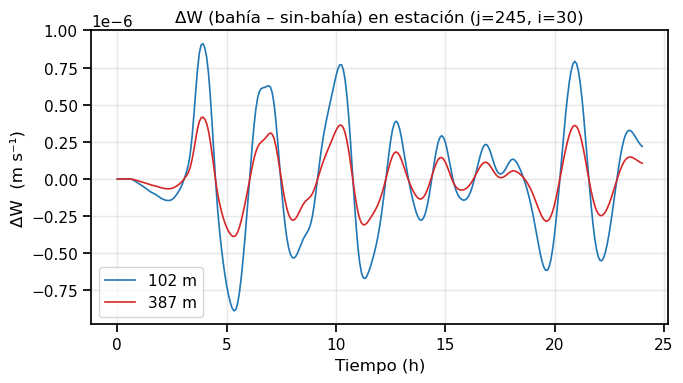

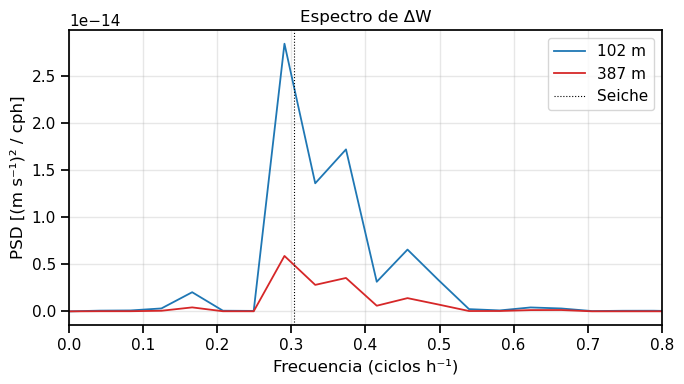

In [8]:
j_i = (245, 30)             # estación
niveles = [100, 400]         # profundidades en metros

out = analizar_w_y_espectro_dosprof(
        nc_bay ,       # netCDF con W – bahía
        nc_nobay ,     # netCDF con W – sin bahía
        time ,      # el mismo vector de segundos
        j_i_station = j_i,
        depth_levels= niveles,
        tmin_horas  = 0,
        save_dir    = "/Volumes/Esteban_SSD/Maestría/MITgcm/verification/Output_IWBay/",
        escenario_tag = "linear",
        formato     = "npy")
